In [20]:
import os
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
import datetime
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.colors import to_rgba
import seaborn as sns
sns.set()
from tqdm.notebook import tqdm
import vector
import itertools
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from collections import defaultdict

import tensorflow as tf
import tensorflow.saved_model
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Add, Activation
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Normalization
from tensorflow.keras.callbacks import Callback
from tensorflow.keras import regularizers
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.models import Model, model_from_json, load_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from lbn import LBN, LBNLayer

import mplhep as hep
hep.style.use("CMS")

print("ok")

ok


In [21]:
import logging
def setup_logger(log_file):
    """
    Sets up a logger that logs messages to both a file and the console.

    Args:
        log_file (str): Path to the log file where logs will be written.

    Returns:
        logging.Logger: Configured logger instance.
    
    The logger:
    - Logs messages at the DEBUG level and above.
    - Outputs logs to both the specified file and the console.
    - Uses a consistent log format including timestamp, log level, filename, and line number.
    """
    # Create a logger                                                                                                                                                             
    logger = logging.getLogger('main')
    logger.setLevel(logging.DEBUG)

    # Create a file handler                                                                                                                                                       
    file_handler = logging.FileHandler(log_file)
    file_handler.setLevel(logging.DEBUG)

    # Create a console handler                                                                                                                                                    
    console_handler = logging.StreamHandler()
    console_handler.setLevel(logging.DEBUG)

    # Create a formatter and add it to the file handler                                                                                                                           
    formatter = logging.Formatter('%(asctime)s,%(msecs)03d %(levelname)-8s [%(filename)s:%(lineno)d] %(message)s','%Y-%m-%d:%H:%M:%S')
    file_handler.setFormatter(formatter)
    console_handler.setFormatter(formatter)

    # Add the file handler to the logger                                                                                                                                          
    logger.addHandler(file_handler)
    logger.addHandler(console_handler)

    return logger

In [22]:
tf.__version__

# List the available physical devices (CPU, GPU)
devices = tf.config.list_physical_devices()
print("\nDevices: ", devices)

# List the available GPUs
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    details = tf.config.experimental.get_device_details(gpus[0])
    print("GPU details: ", details)


Devices:  [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [108]:
# tag_ = "DNN_Higgs_Flat_Feb25"
tag_ = "LBN_Higgs_Flat_March25"
tagdir = os.path.join(os.getcwd(), tag_)
print(tagdir)
if not os.path.exists(tagdir):
    os.mkdir(tagdir)
else:
    print(f"{tag_} exists")

/pbs/home/o/oponcet/private/TauRegression/BasicNN/LBN_Higgs_Flat_March25


In [109]:
# Get the current date and time
dttag = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
n_particles = 10 # why 10? what are these 10 aprticles ? with channel? 
lbn_feat_names = ["E", "px", "py", "pz", "pt", "eta", "phi", "p", "m", "pair_cos","pair_dr"]
train = True # If false, load the model and evaluate
nepochs = 300 # Number of epochs
evaluate = True # If true, evaluate the model
#hereismodel = f"{tagdir}/training_20240426-125220/cp.ckpt"
hereismodeldir = os.path.join(os.getcwd(), "DNN_Higgs_Flat_Feb25")

# A checkpoint (.ckpt) is a snapshot of a model's trainable variables (weights and biases).
# It does not store the model's architecture—only the parameters.
hereismodel = f"{hereismodeldir}/training_1/cp.ckpt"

# Create a directory to store the run logs
runlogdir = os.path.join(tagdir, "runlogs")

if not os.path.exists(runlogdir):
    os.mkdir(runlogdir)

logger = setup_logger(os.path.join(runlogdir, f"runlog_{dttag}.log"))

In [110]:
logger.info(f"date-time      : {dttag}")
logger.info(f"nLBNPart       : {n_particles}") # Number of particles in the LBN
logger.info(f"lbn feat names : {str(lbn_feat_names)}") # Features used in the LBN
logger.info(f"do train       : {train}") # Train the model
logger.info(f"nEpochs        : {nepochs}") # Number of epochs
logger.info(f"model loded    : {hereismodel}") # Model to load
logger.info(f"Out dir        : {tagdir}")   # Output directory

2025-03-17:10:07:47,338 INFO     [2562202180.py:1] date-time      : 20250317_100742
2025-03-17:10:07:47,338 INFO     [2562202180.py:1] date-time      : 20250317_100742
2025-03-17:10:07:47,338 INFO     [2562202180.py:1] date-time      : 20250317_100742
2025-03-17:10:07:47,341 INFO     [2562202180.py:2] nLBNPart       : 10
2025-03-17:10:07:47,341 INFO     [2562202180.py:2] nLBNPart       : 10
2025-03-17:10:07:47,341 INFO     [2562202180.py:2] nLBNPart       : 10
2025-03-17:10:07:47,343 INFO     [2562202180.py:3] lbn feat names : ['E', 'px', 'py', 'pz', 'pt', 'eta', 'phi', 'p', 'm', 'pair_cos', 'pair_dr']
2025-03-17:10:07:47,343 INFO     [2562202180.py:3] lbn feat names : ['E', 'px', 'py', 'pz', 'pt', 'eta', 'phi', 'p', 'm', 'pair_cos', 'pair_dr']
2025-03-17:10:07:47,343 INFO     [2562202180.py:3] lbn feat names : ['E', 'px', 'py', 'pz', 'pt', 'eta', 'phi', 'p', 'm', 'pair_cos', 'pair_dr']
2025-03-17:10:07:47,345 INFO     [2562202180.py:4] do train       : True
2025-03-17:10:07:47,345 INF

In [111]:
#df_ = "GluGluHToTauTauSMdata_ForTrain_Raw_11_simple_IC_20240417_183354.h5"
# df_ = "GluGluHToTauTau_ForTrain_Raw_11_simple_MB_20240501_082537.h5"
#df_ = "GluGluHToTauTauFlat_ForTrain_Raw_11_simple_MB_20240501_082908.h5"
#df_ = "Flat_GluGluHToTauTauSMdata_ForTrain_Raw_11_simple_IC_20240418_192329.h5"


#df_ = "GluGluHToTauTauSMdata_ForTrain_Raw_11_simple_IC_20240416_133720.h5"
#df_ = "GluGluHToTauTauSMdata_ForTrain_Raw_11_simple_MB_20240416_145614.h5"
#df_ = "Flat_GluGluHToTauTauSMdata_ForTrain_Raw_11_simple_IC_20240417_064445.h5"

# df_ = "GluGluHToTauTauFlat_ForTrain_Raw_11_simple_IC_20240627_163559.h5"

df_ = "events_a1a1_new.h5"




df_tag_ = f"""{df_.split(".")[0]}_nPart_{n_particles}_executed_on_{dttag}"""

In [112]:
logger.info(f"dataframe      : {df_}")

2025-03-17:10:07:53,928 INFO     [776286069.py:1] dataframe      : events_a1a1_new.h5
2025-03-17:10:07:53,928 INFO     [776286069.py:1] dataframe      : events_a1a1_new.h5
2025-03-17:10:07:53,928 INFO     [776286069.py:1] dataframe      : events_a1a1_new.h5


In [28]:
# Load the TensorBoard notebook extension
#%reload_ext tensorboard
#from tensorboard import notebook
#notebook.list() # View open TensorBoard instances
## Control TensorBoard display. If no port is provided, 
## the most recently launched TensorBoard is used
#notebook.display(port=6006, height=1000)

In [113]:
def PlotHistory(history, path=None, df_tag_=df_tag_):
    """ Takes history from Keras training and makes loss plots (batch and epoch) and learning rate plots """
    #----- Figure -----#
    # variables = sorted([key for key in history.history.keys() if 'val' not in key and 'val_'+key in history.history.keys()])
    variables = sorted([key for key in history.epochs.keys() if 'val' not in key and 'val_'+key in history.epochs.keys()])
    variables += ["lr"] # learning rate
    N = len(variables)
    print(f"variables: {variables}")
    fig, ax = plt.subplots(N,2,figsize=(12.5,N*2),sharex='col')
    plt.subplots_adjust(left    = 0.1,
                        right   = 0.6,
                        top     = 0.9,
                        bottom  = 0.1,
                        hspace  = 0.5,
                        wspace  = 0.4)
    
    #----- Batch Plots -----#
    for i,var in enumerate(variables):
        ax[i,0].plot(history.batches['batch'],history.batches[var],'k')
        ax[i,0].set_title(var)
        ax[i,0].set_xlabel('Batch')
        
    #----- Epoch Plots -----#
    for i,var in enumerate(variables):
        # ax[i,1].plot(history.epoch,history.history[var],label='train')
        ax[i,1].plot(history.epochs['epoch'],history.epochs[var],label='train')
        print(f"var =  {var}")
        # if 'val_'+var in history.history.keys():
        #     ax[i,1].plot(history.epoch,history.history['val_'+var],label='validation')
        if 'val_'+var in history.epochs.keys():
            ax[i,1].plot(history.epochs['epoch'],history.epochs['val_'+var],label='validation')
        ax[i,1].set_title(var)
        ax[i,1].legend()
        ax[i,1].set_xlabel('Epoch')

    png_name = os.path.join(path,f'Loss_Acc_LR_{df_tag_}.png')
    logger.info(f"Plot saved: {png_name}")
    fig.savefig(png_name, dpi=300)
    print('Curves saved as %s'%png_name)

# #######################################################


def getp4(df, vars=[], LVtype=""):
    """
        df: The main dfataframe
        vars = [p4 components of obj]
        LVtype = ptetaphim / pxpypze
    """
    for var in vars:
        if var not in list(df.keys()):
            df[var] = 0.0
    p4 = None
    if LVtype == "ptetaphim":
        p4 = vector.array({"pt": df[vars[0]].to_numpy(),
                           "eta": df[vars[1]].to_numpy(),
                           "phi": df[vars[2]].to_numpy(),
                           "M": df[vars[3]].to_numpy()})
    elif LVtype == "pxpypze":
        p4 = vector.array({"px": df[vars[0]].to_numpy(),
                           "py": df[vars[1]].to_numpy(),
                           "pz": df[vars[2]].to_numpy(),
                           "E": df[vars[3]].to_numpy()})
        

    return p4

def setp4(df, vars=[]):
    p4 = getp4(df, vars=vars)
    obj = vars[0].split('_')[0]
    num = vars[0].split('_')[1]
    key = f'{obj}_{num}' if len(vars[0].split('_')) > 2 else f'{obj}'

    df[f'{key}_px'] = p4.px
    df[f'{key}_py'] = p4.py
    df[f'{key}_pz'] = p4.pz
    df[f'{key}_E']  = p4.E

In [114]:

# logger = logging.getLogger(__name__)

# def PlotHistory(history, path=None, df_tag_=None):
#     """
#     Generates both batch-wise and epoch-wise training history plots.
    
#     Args:
#         history (tf.keras.callbacks.History): Training history object.
#         path (str, optional): Directory to save the plot.
#         df_tag_ (str, optional): Tag for naming the output file.
    
#     Saves:
#         PNG files with loss, accuracy, and learning rate curves.
#     """
    
#     # Identify metrics with both training and validation data
#     metrics = [key for key in history.history.keys() if 'val_' not in key and 'val_' + key in history.history.keys()]
#     num_metrics = len(metrics)

#     if num_metrics == 0:
#         logger.warning("No matching training and validation metrics found. Check the history object.")
#         return
    
#     logger.info(f"Plotting metrics: {metrics}")

#     # --- EPOCH-BASED PLOTS ---
#     fig, axes = plt.subplots(num_metrics, 1, figsize=(12, num_metrics * 4), sharex=True)
#     fig.subplots_adjust(left=0.1, right=0.95, top=0.9, bottom=0.1, hspace=0.4)
    
#     if num_metrics == 1:  # Ensure `axes` is iterable for a single metric
#         axes = [axes]

#     epochs = history.epoch
#     x_ticks = np.arange(min(epochs), max(epochs) + 1, 5)  # Set x-axis ticks at every 5 epochs

#     # Plot training and validation metrics per epoch
#     for ax, metric in zip(axes, metrics):
#         ax.plot(epochs, history.history[metric], label='Train', color='blue', linewidth=2)
#         if 'val_' + metric in history.history:
#             ax.plot(epochs, history.history['val_' + metric], label='Validation', color='orange', linestyle='dashed', linewidth=2)
        
#         ax.set_title(f"{metric.capitalize()} (Epoch-wise)", fontsize=14, fontweight='bold')
#         ax.set_xlabel('Epoch', fontsize=12)
#         ax.set_ylabel(metric, fontsize=12)
#         ax.set_xticks(x_ticks)  # Set x-axis tick values to every 5 epochs
#         ax.tick_params(axis='both', labelsize=10)
#         ax.legend(fontsize=12)
#         ax.grid(True, linestyle='--', alpha=0.6)

#     # Save epoch-based plots
#     if path and df_tag_:
#         os.makedirs(path, exist_ok=True)
#         epoch_plot_filename = os.path.join(path, f'Loss_Acc_LR_Epoch_{df_tag_}.png')
#         fig.savefig(epoch_plot_filename, dpi=300, bbox_inches='tight')
#         logger.info(f"Epoch plot saved: {epoch_plot_filename}")
#         print(f'Curves saved as {epoch_plot_filename}')
    
#     plt.show()


#     # --- BATCH-BASED PLOTS ---
#     if hasattr(history, "batches") and isinstance(history.batches, dict):
#         batch_metrics = [key for key in history.batches.keys() if key != 'batch']
#         num_batch_metrics = len(batch_metrics)

#         if num_batch_metrics > 0:
#             fig, axes = plt.subplots(num_batch_metrics, 1, figsize=(12, num_batch_metrics * 4), sharex=True)
#             fig.subplots_adjust(left=0.1, right=0.95, top=0.9, bottom=0.1, hspace=0.4)
            
#             if num_batch_metrics == 1:
#                 axes = [axes]

#             batch_numbers = history.batches['batch']
#             x_ticks_batch = np.linspace(min(batch_numbers), max(batch_numbers), num=6, dtype=int)

#             # Plot batch-wise metrics
#             for ax, metric in zip(axes, batch_metrics):
#                 ax.plot(batch_numbers, history.batches[metric], label='Train (Batch)', color='green', linewidth=2)
                
#                 ax.set_title(f"{metric.capitalize()} (Batch-wise)", fontsize=14, fontweight='bold')
#                 ax.set_xlabel('Batch', fontsize=12)
#                 ax.set_ylabel(metric, fontsize=12)
#                 ax.set_xticks(x_ticks_batch)
#                 ax.tick_params(axis='both', labelsize=10)
#                 ax.legend(fontsize=12)
#                 ax.grid(True, linestyle='--', alpha=0.6)

#             # Save batch-based plots
#             batch_plot_filename = os.path.join(path, f'Loss_Acc_LR_Batch_{df_tag_}.png')
#             fig.savefig(batch_plot_filename, dpi=300, bbox_inches='tight')
#             logger.info(f"Batch plot saved: {batch_plot_filename}")
#             print(f'Curves saved as {batch_plot_filename}')
            
#             plt.show()


In [115]:
#indf = "df_DY_v5_processed_scaled_metphi.h5"
#indf = "df_DY_v5_processed.h5"
indf = f"/pbs/home/o/oponcet/private/TauRegression/BasicNN/model/{df_}"

# Load the dataframe from the file in pandas dataframe
df = pd.read_hdf(indf)
#df = df.drop(columns=["total_tau_phi"]) # new

# Drop the rows with NaN values
df = df.dropna()

# Print the first 10 rows of the dataframe
df.head(10)

,pt_tau_1,eta_tau_1,phi_tau_1,mass_tau_1,px_tau_1,py_tau_1,pz_tau_1,energy_tau_1,energy_frac_tau_1,npf_tau_1,charge_pos_tau_1,charge_neg_tau_1,pt_tau_2,eta_tau_2,phi_tau_2,mass_tau_2,px_tau_2,py_tau_2,pz_tau_2,energy_tau_2,energy_frac_tau_2,npf_tau_2,charge_pos_tau_2,charge_neg_tau_2,pt_jet_1,eta_jet_1,phi_jet_1,mass_jet_1,px_jet_1,py_jet_1,pz_jet_1,energy_jet_1,pt_jet_2,eta_jet_2,phi_jet_2,mass_jet_2,px_jet_2,py_jet_2,pz_jet_2,energy_jet_2,pt_jet_3,eta_jet_3,phi_jet_3,mass_jet_3,px_jet_3,py_jet_3,pz_jet_3,energy_jet_3,pt_jet_4,eta_jet_4,phi_jet_4,mass_jet_4,px_jet_4,py_jet_4,pz_jet_4,energy_jet_4,pt_jet_5,eta_jet_5,phi_jet_5,mass_jet_5,px_jet_5,py_jet_5,pz_jet_5,energy_jet_5,pt_jet_6,eta_jet_6,phi_jet_6,mass_jet_6,px_jet_6,py_jet_6,pz_jet_6,energy_jet_6,pt_met,phi_met,px_met,py_met,pz_met,energy_met,covxx_met,covxy_met,covyy_met,sig_met,pt_gentau_1,eta_gentau_1,phi_gentau_1,px_gentau_1,py_gentau_1,pz_gentau_1,energy_frac_gentau_1,pt_gentau_2,eta_gentau_2,phi_gentau_2,px_gentau_2,py_gentau_2,pz_gentau_2,energy_frac_gentau_2,x_gen_R1,y_gen_R1,z_gen_R1,x_gen_R2,y_gen_R2,z_gen_R2,x_gen_R1_perp,y_gen_R1_perp,z_gen_R1_perp,x_gen_R2_perp,y_gen_R2_perp,z_gen_R2_perp,phicp_gen,x_reco_R1,y_reco_R1,z_reco_R1,x_reco_R2,y_reco_R2,z_reco_R2,x_reco_R1_perp,y_reco_R1_perp,z_reco_R1_perp,x_reco_R2_perp,y_reco_R2_perp,z_reco_R2_perp,phicp_reco,x_reco_gentau_R1,y_reco_gentau_R1,z_reco_gentau_R1,x_reco_gentau_R2,y_reco_gentau_R2,z_reco_gentau_R2,x_reco_gentau_R1_perp,y_reco_gentau_R1_perp,z_reco_gentau_R1_perp,x_reco_gentau_R2_perp,y_reco_gentau_R2_perp,z_reco_gentau_R2_perp,phicp_reco_gentau,spinner_wt_cp_even,spinner_wt_cp_odd,spinner_wt_cp_mm,eratag,pt_h1_pi1_gen,pt_h1_pi2_gen,pt_h1_pi3_gen,pt_h2_pi1_gen,pt_h2_pi2_gen,pt_h2_pi3_gen,eta_h1_pi1_gen,eta_h1_pi2_gen,eta_h1_pi3_gen,eta_h2_pi1_gen,eta_h2_pi2_gen,eta_h2_pi3_gen,phi_h1_pi1_gen,phi_h1_pi2_gen,phi_h1_pi3_gen,phi_h2_pi1_gen,phi_h2_pi2_gen,phi_h2_pi3_gen,mass_h1_pi1_gen,mass_h1_pi2_gen,mass_h1_pi3_gen,mass_h2_pi1_gen,mass_h2_pi2_gen,mass_h2_pi3_gen,px_h1_pi1_gen,px_h1_pi2_gen,px_h1_pi3_gen,px_h2_pi1_gen,px_h2_pi2_gen,px_h2_pi3_gen,py_h1_pi1_gen,py_h1_pi2_gen,py_h1_pi3_gen,py_h2_pi1_gen,py_h2_pi2_gen,py_h2_pi3_gen,pz_h1_pi1_gen,pz_h1_pi2_gen,pz_h1_pi3_gen,pz_h2_pi1_gen,pz_h2_pi2_gen,pz_h2_pi3_gen,energy_h1_pi1_gen,energy_h1_pi2_gen,energy_h1_pi3_gen,energy_h2_pi1_gen,energy_h2_pi2_gen,energy_h2_pi3_gen,charge_pos_h1_pi1_gen,charge_pos_h1_pi2_gen,charge_pos_h1_pi3_gen,charge_pos_h2_pi1_gen,charge_pos_h2_pi2_gen,charge_pos_h2_pi3_gen,charge_neg_h1_pi1_gen,charge_neg_h1_pi2_gen,charge_neg_h1_pi3_gen,charge_neg_h2_pi1_gen,charge_neg_h2_pi2_gen,charge_neg_h2_pi3_gen,efrac_h1_pi1_gen,efrac_h1_pi2_gen,efrac_h1_pi3_gen,efrac_h2_pi1_gen,efrac_h2_pi2_gen,efrac_h2_pi3_gen,dr_h1_pi1_gen,dr_h1_pi2_gen,dr_h1_pi3_gen,dr_h2_pi1_gen,dr_h2_pi2_gen,dr_h2_pi3_gen,dphi_h1_pi1_gen,dphi_h1_pi2_gen,dphi_h1_pi3_gen,dphi_h2_pi1_gen,dphi_h2_pi2_gen,dphi_h2_pi3_gen,pt_h1_pi1_reco,pt_h1_pi2_reco,pt_h1_pi3_reco,pt_h2_pi1_reco,pt_h2_pi2_reco,pt_h2_pi3_reco,eta_h1_pi1_reco,eta_h1_pi2_reco,eta_h1_pi3_reco,eta_h2_pi1_reco,eta_h2_pi2_reco,eta_h2_pi3_reco,phi_h1_pi1_reco,phi_h1_pi2_reco,phi_h1_pi3_reco,phi_h2_pi1_reco,phi_h2_pi2_reco,phi_h2_pi3_reco,mass_h1_pi1_reco,mass_h1_pi2_reco,mass_h1_pi3_reco,mass_h2_pi1_reco,mass_h2_pi2_reco,mass_h2_pi3_reco,px_h1_pi1_reco,px_h1_pi2_reco,px_h1_pi3_reco,px_h2_pi1_reco,px_h2_pi2_reco,px_h2_pi3_reco,py_h1_pi1_reco,py_h1_pi2_reco,py_h1_pi3_reco,py_h2_pi1_reco,py_h2_pi2_reco,py_h2_pi3_reco,pz_h1_pi1_reco,pz_h1_pi2_reco,pz_h1_pi3_reco,pz_h2_pi1_reco,pz_h2_pi2_reco,pz_h2_pi3_reco,energy_h1_pi1_reco,energy_h1_pi2_reco,energy_h1_pi3_reco,energy_h2_pi1_reco,energy_h2_pi2_reco,energy_h2_pi3_reco,charge_pos_h1_pi1_reco,charge_pos_h1_pi2_reco,charge_pos_h1_pi3_reco,charge_pos_h2_pi1_reco,charge_pos_h2_pi2_reco,charge_pos_h2_pi3_reco,charge_neg_h1_pi1_reco,charge_neg_h1_pi2_reco,charge_neg_h1_pi3_reco,charge_neg_h2_pi1_reco,charge_neg_h2_pi2_reco,charge_neg_h2_pi3_reco,efrac_h1_pi1_reco,efrac_h1_p

In [116]:
df["ptlog_gentau_1"] = np.log(df["pt_gentau_1"])
df["ptlog_gentau_2"] = np.log(df["pt_gentau_2"])

In [33]:
#hasnan = list(df.isnull().any())
#for i, col in enumerate(df.keys()):
#    print(f"{col}:\t\t {hasnan[i]}")

In [34]:
#import awkward as ak
#arr = ak.Array((df["rawPNetVSe_tau_1"]).to_numpy())
#ak.to_list(ak.sort(arr))

In [117]:
logger.info(f"df keys         :\n{list(df.keys())}")

2025-03-17:10:08:14,241 INFO     [1491129398.py:1] df keys         :
['pt_tau_1', 'eta_tau_1', 'phi_tau_1', 'mass_tau_1', 'px_tau_1', 'py_tau_1', 'pz_tau_1', 'energy_tau_1', 'energy_frac_tau_1', 'npf_tau_1', 'charge_pos_tau_1', 'charge_neg_tau_1', 'pt_tau_2', 'eta_tau_2', 'phi_tau_2', 'mass_tau_2', 'px_tau_2', 'py_tau_2', 'pz_tau_2', 'energy_tau_2', 'energy_frac_tau_2', 'npf_tau_2', 'charge_pos_tau_2', 'charge_neg_tau_2', 'pt_jet_1', 'eta_jet_1', 'phi_jet_1', 'mass_jet_1', 'px_jet_1', 'py_jet_1', 'pz_jet_1', 'energy_jet_1', 'pt_jet_2', 'eta_jet_2', 'phi_jet_2', 'mass_jet_2', 'px_jet_2', 'py_jet_2', 'pz_jet_2', 'energy_jet_2', 'pt_jet_3', 'eta_jet_3', 'phi_jet_3', 'mass_jet_3', 'px_jet_3', 'py_jet_3', 'pz_jet_3', 'energy_jet_3', 'pt_jet_4', 'eta_jet_4', 'phi_jet_4', 'mass_jet_4', 'px_jet_4', 'py_jet_4', 'pz_jet_4', 'energy_jet_4', 'pt_jet_5', 'eta_jet_5', 'phi_jet_5', 'mass_jet_5', 'px_jet_5', 'py_jet_5', 'pz_jet_5', 'energy_jet_5', 'pt_jet_6', 'eta_jet_6', 'phi_jet_6', 'mass_jet_6', 'p

In [ ]:
num_keys   = ['pt_tau_1', 'pt_tau_2','eta_tau_1', 'eta_tau_2', 'phi_tau_1', 'phi_tau_2',
              'mass_tau_1', 'mass_tau_2', #'dxy_tau_1', 'dxy_tau_2', 'dz_tau_1', 'dz_tau_2',
              #'rawIsodR03_tau_1', 'rawIsodR03_tau_2', # new 
              #'leadTkPtOverTauPt_tau_1',  # new
              #'leadTkPtOverTauPt_tau_2',  # new
              #'rawPNetVSe_tau_1', 'rawPNetVSe_tau_2', # new
              #'rawPNetVSjet_tau_1', 'rawPNetVSjet_tau_2', # new
              #'rawPNetVSmu_tau_1', 'rawPNetVSmu_tau_2', # new
              #'probDM0PNet_tau_1', 'probDM0PNet_tau_2',
              #'probDM1PNet_tau_1', 'probDM1PNet_tau_2', # new
              #'probDM2PNet_tau_1', 'probDM2PNet_tau_2',
              #'probDM10PNet_tau_1', 'probDM10PNet_tau_2',
              #'probDM11PNet_tau_1', 'probDM11PNet_tau_2',
              'pt_jet_1', 'pt_jet_2', 'pt_jet_3', 'pt_jet_4', 
              'eta_jet_1', 'eta_jet_2', 'eta_jet_3', 'eta_jet_4',
              'phi_jet_1', 'phi_jet_2', 'phi_jet_3', 'phi_jet_4',
              'mass_jet_1', 'mass_jet_2', 'mass_jet_3', 'mass_jet_4',
              #'btagPNetB_jet_1', 'btagPNetB_jet_2', 'btagPNetB_jet_3', 'btagPNetB_jet_4',
              'npf_tau_1', 'npf_tau_2',   ## NEW !!
            #   'ptfrac_tau_1', 'ptfrac_tau_2',  ## NEW !!
              'energy_frac_tau_1', 'energy_frac_tau_2',  ## NEW !!
              #'pf_dphi_pt_frac_tau_1', 'pf_dphi_pt_frac_tau_2', 
              #'pf_deta_pt_frac_tau_1', 'pf_deta_pt_frac_tau_2', 
            #   'pt_MET', 'phi_MET', 
            #   'covXX_MET', 'covXY_MET', 'covYY_MET', 'sumEt_MET',  # new
            #   'significance_MET',  # new
              'pt_met', 'phi_met', 'covxx_met', 'covxy_met', 'covyy_met', 'energy_met', 'sig_met',  # new
              #'nJet', 
              #'nPV', 
              #'HT', #'MT_total'
             ]
# cat_keys = ['charge_-1_tau_1','charge_1_tau_1',
#             'charge_-1_tau_2','charge_1_tau_2',
#             #'decayModePNet_0_tau_1', 'decayModePNet_1_tau_1', 'decayModePNet_2_tau_1', ## NEW !!
#             #'decayModePNet_10_tau_1', 'decayModePNet_11_tau_1', ## NEW !!
#             #'decayModePNet_0_tau_2', 'decayModePNet_1_tau_2', 'decayModePNet_2_tau_2', ## NEW !!
#             #'decayModePNet_10_tau_2', 'decayModePNet_11_tau_2' ## NEW !!
#            ]

cat_keys = ['charge_pos_tau_1', 'charge_neg_tau_1',
            'charge_pos_tau_2', 'charge_neg_tau_2']


target_keys = ['ptlog_gentau_1', 'eta_gentau_1', 'phi_gentau_1', 
               'ptlog_gentau_2', 'eta_gentau_2', 'phi_gentau_2',
               'x_gen_R1_perp', 'y_gen_R1_perp', 'z_gen_R1_perp',
               'x_gen_R2_perp', 'y_gen_R2_perp', 'z_gen_R2_perp'
              ]
#               'k1x', 'k1y', 'k1z',
#               'k2x', 'k2y', 'k2z']
#target_keys = ['h1x', 'h1y', 'h1z',
#               'h2x', 'h2y', 'h2z']

# extra_keys = ["pt_tau1pi_1","eta_tau1pi_1","phi_tau1pi_1","mass_tau1pi_1",
#               "pt_tau2pi_1","eta_tau2pi_1","phi_tau2pi_1","mass_tau2pi_1",
#               "pt_tau1pi0_1","eta_tau1pi0_1","phi_tau1pi0_1","mass_tau1pi0_1",
#               "pt_tau2pi0_1","eta_tau2pi0_1","phi_tau2pi0_1","mass_tau2pi0_1",
#               "phicp", "phi_cp_det",
#               'pt_gentau_1', #'eta_gentau_1', 'phi_gentau_1', 
#               'pt_gentau_2', #'eta_gentau_2', 'phi_gentau_2',
#               'h1x', 'h1y', 'h1z', 'h2x', 'h2y', 'h2z',
#               'k1x', 'k1y', 'k1z', 'k2x', 'k2y', 'k2z',
#              ]

extra_keys = ["pt_h1_pi1_gen", "eta_h1_pi1_gen", "phi_h1_pi1_gen", "mass_h1_pi1_gen",
              "pt_h1_pi2_gen", "eta_h1_pi2_gen", "phi_h1_pi2_gen", "mass_h1_pi2_gen",
              "pt_h1_pi3_gen", "eta_h1_pi3_gen", "phi_h1_pi3_gen", "mass_h1_pi3_gen",
              "pt_h2_pi1_gen", "eta_h2_pi1_gen", "phi_h2_pi1_gen", "mass_h2_pi1_gen",
              "pt_h2_pi2_gen", "eta_h2_pi2_gen", "phi_h2_pi2_gen", "mass_h2_pi2_gen",
              "pt_h2_pi3_gen", "eta_h2_pi3_gen", "phi_h2_pi3_gen", "mass_h2_pi3_gen",
              "pt_h1_pi1_reco", "eta_h1_pi1_reco", "phi_h1_pi1_reco", "mass_h1_pi1_reco",
              "pt_h1_pi2_reco", "eta_h1_pi2_reco", "phi_h1_pi2_reco", "mass_h1_pi2_reco",
              "pt_h1_pi3_reco", "eta_h1_pi3_reco", "phi_h1_pi3_reco", "mass_h1_pi3_reco",
              "pt_h2_pi1_reco", "eta_h2_pi1_reco", "phi_h2_pi1_reco", "mass_h2_pi1_reco",
              "pt_h2_pi2_reco", "eta_h2_pi2_reco", "phi_h2_pi2_reco", "mass_h2_pi2_reco",
              "pt_h2_pi3_reco", "eta_h2_pi3_reco", "phi_h2_pi3_reco", "mass_h2_pi3_reco",
              "phicp_gen", "phicp_reco",
              "x_reco_R1_perp", "y_reco_R1_perp", "z_reco_R1_perp",
              "x_reco_R2_perp", "y_reco_R2_perp", "z_reco_R2_perp",
             ]

keysTokeep = num_keys + cat_keys + target_keys + extra_keys

In [119]:
logger.info(f"main features        : {str(num_keys+cat_keys)}")
logger.info(f"targets              : {str(target_keys)}")
logger.info(f"extra                : {str(extra_keys)}")

2025-03-17:10:08:19,381 INFO     [2678812420.py:1] main features        : ['pt_tau_1', 'pt_tau_2', 'eta_tau_1', 'eta_tau_2', 'phi_tau_1', 'phi_tau_2', 'mass_tau_1', 'mass_tau_2', 'pt_jet_1', 'pt_jet_2', 'pt_jet_3', 'pt_jet_4', 'eta_jet_1', 'eta_jet_2', 'eta_jet_3', 'eta_jet_4', 'phi_jet_1', 'phi_jet_2', 'phi_jet_3', 'phi_jet_4', 'mass_jet_1', 'mass_jet_2', 'mass_jet_3', 'mass_jet_4', 'npf_tau_1', 'npf_tau_2', 'energy_frac_tau_1', 'energy_frac_tau_2', 'pt_met', 'phi_met', 'covxx_met', 'covxy_met', 'covyy_met', 'energy_met', 'sig_met', 'charge_pos_tau_1', 'charge_neg_tau_1', 'charge_pos_tau_2', 'charge_neg_tau_2']
2025-03-17:10:08:19,381 INFO     [2678812420.py:1] main features        : ['pt_tau_1', 'pt_tau_2', 'eta_tau_1', 'eta_tau_2', 'phi_tau_1', 'phi_tau_2', 'mass_tau_1', 'mass_tau_2', 'pt_jet_1', 'pt_jet_2', 'pt_jet_3', 'pt_jet_4', 'eta_jet_1', 'eta_jet_2', 'eta_jet_3', 'eta_jet_4', 'phi_jet_1', 'phi_jet_2', 'phi_jet_3', 'phi_jet_4', 'mass_jet_1', 'mass_jet_2', 'mass_jet_3', 'mass_j

In [120]:
df = df[keysTokeep]


In [121]:
tau1p4 = getp4(df, vars=["pt_tau_1", "eta_tau_1", "phi_tau_1", "mass_tau_1"], LVtype="ptetaphim")
tau2p4 = getp4(df, vars=["pt_tau_2", "eta_tau_2", "phi_tau_2", "mass_tau_2"], LVtype="ptetaphim")

tausp4 = tau1p4 + tau2p4
print(tausp4.mass)
#plt.hist(tausp4.mass, bins=100, range=[30,130])
#plt.show()
#df["H_vism"] = tausp4.mass
#target_keys = target_keys + ["H_vism"]

[ 93.30126125  94.68742976 114.72035628 ... 115.65917871 107.33859188
 117.56589391]


In [122]:
#df_train, df_test = train_test_split(df,  test_size=0.2,  random_state=42, shuffle=True)
df_train, df_test = train_test_split(df,  test_size=0.2,  shuffle=False) # # Split data: 80% training, 20% testing

In [123]:
# Split features (X) and target values (Y) from the training dataset
df_train_x = df_train.drop(columns=target_keys+extra_keys)  # Drop target & extra columns, keeping only features

print("df_train_x key : ", list(df_train_x.keys()))

df_train_y = df_train[target_keys]  # Keep only the target columns (labels)

print("df_train_y key, target column: ", list(df_train_y.keys()))

# Split features (X) and target values (Y) from the test dataset
df_test_x = df_test.drop(columns=target_keys+extra_keys)  # Drop target & extra columns, keeping only features
df_test_y = df_test[target_keys]  # Keep only the target columns (labels)

# The following lines are commented out but would handle a specific column ("met_phi_raw")
# If uncommented, they would separate "met_phi_raw" as its own dataset and remove it from feature columns.

# Extract the "met_phi_raw" column separately from the training and test features
# df2_met_raw_phi_train = df_train_x[["met_phi_raw"]]
# df2_met_raw_phi_test  = df_test_x[["met_phi_raw"]]

# Remove "met_phi_raw" from the feature set (if needed)
# df_train_x = df_train_x.drop(columns=["met_phi_raw"])
# df_test_x = df_test_x.drop(columns=["met_phi_raw"])

# Get a list of feature column names (after dropping target & extra keys)
feats = list(df_train_x.keys())  # Store feature names as a list for later use
print("feats: ", feats)


df_train_x key :  ['pt_tau_1', 'pt_tau_2', 'eta_tau_1', 'eta_tau_2', 'phi_tau_1', 'phi_tau_2', 'mass_tau_1', 'mass_tau_2', 'pt_jet_1', 'pt_jet_2', 'pt_jet_3', 'pt_jet_4', 'eta_jet_1', 'eta_jet_2', 'eta_jet_3', 'eta_jet_4', 'phi_jet_1', 'phi_jet_2', 'phi_jet_3', 'phi_jet_4', 'mass_jet_1', 'mass_jet_2', 'mass_jet_3', 'mass_jet_4', 'npf_tau_1', 'npf_tau_2', 'energy_frac_tau_1', 'energy_frac_tau_2', 'pt_met', 'phi_met', 'covxx_met', 'covxy_met', 'covyy_met', 'energy_met', 'sig_met', 'charge_pos_tau_1', 'charge_neg_tau_1', 'charge_pos_tau_2', 'charge_neg_tau_2']
df_train_y key, target column:  ['ptlog_gentau_1', 'eta_gentau_1', 'phi_gentau_1', 'ptlog_gentau_2', 'eta_gentau_2', 'phi_gentau_2', 'x_gen_R1_perp', 'y_gen_R1_perp', 'z_gen_R1_perp', 'x_gen_R2_perp', 'y_gen_R2_perp', 'z_gen_R2_perp']
feats:  ['pt_tau_1', 'pt_tau_2', 'eta_tau_1', 'eta_tau_2', 'phi_tau_1', 'phi_tau_2', 'mass_tau_1', 'mass_tau_2', 'pt_jet_1', 'pt_jet_2', 'pt_jet_3', 'pt_jet_4', 'eta_jet_1', 'eta_jet_2', 'eta_jet_3', '

In [124]:
if evaluate:
    df = pd.concat([df_train, df_test], axis=0)

In [125]:
df_train_x

,pt_tau_1,pt_tau_2,eta_tau_1,eta_tau_2,phi_tau_1,phi_tau_2,mass_tau_1,mass_tau_2,pt_jet_1,pt_jet_2,pt_jet_3,pt_jet_4,eta_jet_1,eta_jet_2,eta_jet_3,eta_jet_4,phi_jet_1,phi_jet_2,phi_jet_3,phi_jet_4,mass_jet_1,mass_jet_2,mass_jet_3,mass_jet_4,npf_tau_1,npf_tau_2,energy_frac_tau_1,energy_frac_tau_2,pt_met,phi_met,covxx_met,covxy_met,covyy_met,energy_met,sig_met,charge_pos_tau_1,charge_neg_tau_1,charge_pos_tau_2,charge_neg_tau_2
0,120.848686,90.070480,-0.010361,0.180603,0.090302,-0.813354,1.367587,1.276216,161.882462,112.902031,0.000000,0.000000,-2.408203,1.092285,0.000000,0.000000,3.135254,2.506348,0.000000,0.000000,28.010839,8.488106,0.000000,0.00000,3,3,0.983167,0.983263,35.642590,0.092056,36736.000,1100.0000,19264.0,35.642590,0.034576,0,1,1,0
1,50.682392,45.924042,0.833252,0.236511,0.574829,-1.831299,1.113337,1.100426,56.103741,0.000000,0.000000,0.000000,0.573242,0.000000,0.000000,0.000000,2.025391,0.000000,0.000000,0.000000,10.715024,0.000000,0.000000,0.00000,3,3,0.983441,0.983497,59.311504,-2.229492,161.500,81.5000,198.0,59.311504,13.367188,0,1,1,0
2,75.372231,42.470474,0.248566,0.577026,-2.720703,0.423035,1.562247,1.237482,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,6,5,0.812339,0.818288,10.627472,0.571167,276.000,86.0000,203.5,10.627472,0.339111,0,1,1,0
3,77.837379,43.544670,-0.134674,-1.817383,1.703125,1.990967,1.051761,1.371560,173.372604,0.000000,0.000000,0.000000,0.506104,0.000000,0.000000,0.000000,-1.293213,0.000000,0.000000,0.000000,17.324615,0.000000,0.000000,0.00000,3,3,0.983350,0.983411,14.812046,-2.894043,11712.000,-1460.0000,22080.0,14.812046,0.018951,1,0,0,1
4,66.313194,50.168270,1.573975,0.777466,1.128906,-2.488770,1.396389,1.303031,54.686615,50.257301,25.764585,0.000000,-2.538086,2.081543,1.809814,0.000000,2.979980,-0.035622,-1.605957,0.000000,5.243237,8.929362,5.488805,0.00000,3,3,0.983507,0.982974,27.658617,-1.460693,394.000,65.0000,417.0,27.658617,1.953125,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31016,61.769169,57.854908,0.400269,0.629395,1.005615,-1.529785,1.332464,1.036361,40.885136,25.688353,0.000000,0.000000,2.109375,-0.222198,0.000000,0.000000,-3.047852,1.600342,0.000000,0.000000,3.635144,3.309015,0.000000,0.00000,3,3,1.002884,1.002382,29.571066,0.586792,96.000,28.7500,334.0,29.571066,6.566406,1,0,0,1
31017,88.520767,42.662472,-1.452393,-0.794678,0.066727,1.630615,1.174672,1.401620,64.598602,55.920444,30.921997,22.715992,-1.897949,-2.126465,-2.433594,-1.734375,-2.193848,2.854004,-2.325684,-1.653809,10.892911,8.679220,4.875684,4.08153,3,3,1.002788,1.002803,22.255299,1.239014,640.000,107.0000,430.0,22.255299,1.036133,0,1,1,0
31018,95.333443,51.648705,1.988525,1.035889,-3.005371,-1.899902,0.848374,1.077270,134.548035,0.000000,0.000000,0.000000,-0.140167,0.000000,0.000000,0.000000,0.414429,0.000000,0.000000,0.000000,16.521246,0.000000,0.000000,0.00000,3,3,1.002668,1.002734,15.674456,-2.331055,918.000,142.0000,361.0,15.674456,0.403320,1,0,0,1
31019,175.002289,53.363300,-0.460144,-0.672485,-2.157715,-0.896240,1.185387,0.944803,171.748489,57.362396,0.000000,0.000000,-1.993408,-2.429688,0.000000,0.000000,1.011719,2.188477,0.000000,0.000000,18.258455,10.954297,0.000000,0.00000,3,3,1.002644,1.002541,28.936924,-2.633789,395.000,288.0000,782.0,28.936924,1.650391,1,0,0,1


In [126]:
df_train_y

,ptlog_gentau_1,eta_gentau_1,phi_gentau_1,ptlog_gentau_2,eta_gentau_2,phi_gentau_2,x_gen_R1_perp,y_gen_R1_perp,z_gen_R1_perp,x_gen_R2_perp,y_gen_R2_perp,z_gen_R2_perp
0,5.087596,-0.012299,0.092529,4.777020,0.185547,-0.816406,0.421470,-0.363333,-0.615940,-0.202667,-0.034438,-0.572108
1,4.034241,0.839844,0.568359,4.269697,0.226074,-1.824219,-0.101594,0.389380,-0.904312,0.170249,-0.382086,0.759268
2,4.151040,0.251953,-2.718750,4.092259,0.572266,0.412109,0.056492,-0.430687,0.795116,-0.357880,0.754697,0.135273
3,4.564348,-0.128418,1.707031,3.781345,-1.820312,1.992188,0.767613,-0.369013,0.245248,-0.599772,0.622813,-0.422620
4,4.189655,1.574219,1.132812,3.974998,0.781250,-2.484375,0.298938,0.052465,-0.492497,-0.454371,-0.115837,0.805522
...,...,...,...,...,...,...,...,...,...,...,...,...
31016,4.153006,0.401367,1.007812,4.193435,0.636719,-1.531250,0.585827,-0.115722,0.340257,-0.023944,-0.066376,-0.547700
31017,4.665795,-1.449219,0.064209,4.092259,-0.792969,1.636719,0.100032,-0.375512,0.551143,-0.290608,0.167879,-0.521180
31018,4.764308,1.988281,-3.007812,4.147095,1.035156,-1.890625,-0.771162,-0.194784,-0.054192,-0.403000,0.353334,-0.449788
31019,5.285739,-0.460938,-2.156250,4.000492,-0.671875,-0.894531,0.175294,-0.403533,-0.341868,0.111803,-0.323011,0.331449


In [127]:
df_train_x.keys()

Index(['pt_tau_1', 'pt_tau_2', 'eta_tau_1', 'eta_tau_2', 'phi_tau_1',
       'phi_tau_2', 'mass_tau_1', 'mass_tau_2', 'pt_jet_1', 'pt_jet_2',
       'pt_jet_3', 'pt_jet_4', 'eta_jet_1', 'eta_jet_2', 'eta_jet_3',
       'eta_jet_4', 'phi_jet_1', 'phi_jet_2', 'phi_jet_3', 'phi_jet_4',
       'mass_jet_1', 'mass_jet_2', 'mass_jet_3', 'mass_jet_4', 'npf_tau_1',
       'npf_tau_2', 'energy_frac_tau_1', 'energy_frac_tau_2', 'pt_met',
       'phi_met', 'covxx_met', 'covxy_met', 'covyy_met', 'energy_met',
       'sig_met', 'charge_pos_tau_1', 'charge_neg_tau_1', 'charge_pos_tau_2',
       'charge_neg_tau_2'],
      dtype='object')

## Data engineering for LBN 

In [128]:
def dataset_LBN():    
    import vector
    df_train_x_copy = df_train_x.copy()
    df_test_x_copy = df_test_x.copy()

    def getp4(df, vars=[]):
        #for var in vars:
        #    if var not in list(df.keys()):
        #        df[var] = 0.0
        p4 = vector.array({"pt": df[vars[0]].to_numpy(),
                           "eta": df[vars[1]].to_numpy() if vars[1] in list(df.keys()) else np.zeros_like(df[vars[0]].to_numpy()),
                           "phi": df[vars[2]].to_numpy() if vars[2] in list(df.keys()) else np.zeros_like(df[vars[0]].to_numpy()),
                           "M": df[vars[3]].to_numpy() if vars[3] in list(df.keys()) else np.zeros_like(df[vars[0]].to_numpy())})

        return p4

    def setp4(df, vars=[]):
        p4 = getp4(df, vars=vars)
        obj = vars[0].split('_')[1]
        num = vars[0].split('_')[-1]
        key = f'{obj}_{num}' if len(vars[0].split('_')) > 2 else f'{obj}'

        df[f'px_{key}'] = p4.px
        df[f'py_{key}'] = p4.py
        df[f'pz_{key}'] = p4.pz
        df[f'E_{key}']  = p4.E



    # Basics = [['pt_tau_1','eta_tau_1','phi_tau_1','mass_tau_1'],
    #           ['pt_tau_2','eta_tau_2','phi_tau_2','mass_tau_2'],
    #           ['pt_jet_1','eta_jet_1','phi_jet_1','mass_jet_1'],
    #           ['pt_jet_2','eta_jet_2','phi_jet_2','mass_jet_2'],
    #           ['pt_jet_3','eta_jet_3','phi_jet_3','mass_jet_3'],
    #           ['pt_jet_4','eta_jet_4','phi_jet_4','mass_jet_4'],
    #           ['pt_MET','eta_MET','phi_MET','mass_MET']]

    Basics = [['pt_tau_1','eta_tau_1','phi_tau_1','mass_tau_1'],
              ['pt_tau_2','eta_tau_2','phi_tau_2','mass_tau_2'],
              ['pt_jet_1','eta_jet_1','phi_jet_1','mass_jet_1'],
              ['pt_jet_2','eta_jet_2','phi_jet_2','mass_jet_2'],
              ['pt_jet_3','eta_jet_3','phi_jet_3','mass_jet_3'],
              ['pt_jet_4','eta_jet_4','phi_jet_4','mass_jet_4'],
              ['pt_met','eta_met','phi_met','mass_met']]     

    for varlist in Basics:
        setp4(df_train_x_copy, vars=varlist)
        setp4(df_test_x_copy, vars=varlist)


    DNNsToDrop = np.array(Basics).reshape(-1)    
    #print(DNNsToDrop)

    LBNsToKeep = np.char.replace(DNNsToDrop, "pt", "px")
    LBNsToKeep = np.char.replace(LBNsToKeep, "eta", "py")
    LBNsToKeep = np.char.replace(LBNsToKeep, "phi", "pz")
    LBNsToKeep = np.char.replace(LBNsToKeep, "mass", "E")
    LBNsToKeep = list(LBNsToKeep)
    #print(LBNsToKeep)

    #df_train_x_DNN = df_train_x_copy.drop(columns=list(DNNsToDrop)+LBNsToKeep)
    #df_test_x_DNN = df_test_x_copy.drop(columns=list(DNNsToDrop)+LBNsToKeep)
    df_train_x_DNN = df_train_x_copy.drop(columns=LBNsToKeep)
    df_test_x_DNN = df_test_x_copy.drop(columns=LBNsToKeep)

    df_train_x_LBN = df_train_x_copy[LBNsToKeep]
    df_test_x_LBN  = df_test_x_copy[LBNsToKeep]


    ##df_train_x_DNN
    ##df_train_x_DNN
    ##df_train_x_LBN
    ##df_test_x_LBN
    
    #cols_cat = [x for x in list(df_train_x_DNN.keys()) if x.split('_')[0] == 'cat']
    #cols_num = [x for x in list(df_train_x_DNN.keys()) if x.split('_')[0] != 'cat']
    
    x_train_DNN_numerical = df_train_x_DNN[num_keys].to_numpy()
    x_train_DNN_categorical = df_train_x_DNN[cat_keys].to_numpy()
    x_test_DNN_numerical = df_test_x_DNN[num_keys].to_numpy()
    x_test_DNN_categorical = df_test_x_DNN[cat_keys].to_numpy()

    #x_train_DNN = df_train_x_DNN.to_numpy()
    #x_test_DNN = df_test_x_DNN.to_numpy()

    ### ----- Scaling ----- ###
    # Create an instance of StandardScaler, which standardizes features by removing the mean and scaling to unit variance.
    scaler1 = preprocessing.StandardScaler()
    # Fit the scaler to the training data and transform it, i.e., standardize the training features (x_train_DNN_numerical).
    # This calculates the mean and standard deviation from the training data, then applies the scaling.
    x_train_DNN_numerical = scaler1.fit_transform(x_train_DNN_numerical)

    # Apply the same transformation (using the same mean and standard deviation) to the test data (x_test_DNN_numerical).
    # This ensures that the test data is scaled based on the statistics of the training data, maintaining consistency.
    x_test_DNN_numerical  = scaler1.transform(x_test_DNN_numerical)

    x_train_DNN = np.concatenate([x_train_DNN_numerical, x_train_DNN_categorical], axis=1)
    x_test_DNN  = np.concatenate([x_test_DNN_numerical, x_test_DNN_categorical], axis=1)
    ### ------------------- ###
    
    #x_train_DNN = df_train_x_DNN.to_numpy()
    #x_test_DNN  = df_test_x_DNN.to_numpy()
    
    x_train_LBN_ = df_train_x_LBN.to_numpy()
    x_test_LBN_ = df_test_x_LBN.to_numpy()

    ### ----- Scaling ----- ###
    #scaler2 = preprocessing.StandardScaler()
    #x_train_LBN_ = scaler2.fit_transform(x_train_LBN_)
    #x_test_LBN_  = scaler2.transform(x_test_LBN_)
    ### ------------------- ###
    
    x_train_LBN = x_train_LBN_.reshape(-1, x_train_LBN_.shape[-1]//4, 4)
    x_test_LBN = x_test_LBN_.reshape(-1, x_test_LBN_.shape[-1]//4, 4)

    print(x_train_LBN.shape, x_train_DNN.shape)
    print(x_train_LBN.shape, x_test_DNN.shape)
    
    """
    plt.figure(figsize=(20,20))
    for idx, key in enumerate(list(df_train_x_LBN.keys())):
        idx=idx+1
        ax = plt.subplot(7,4,idx)
        arr = x_train_LBN_[:,(idx-1):idx].reshape(-1)
        #print(arr)
        ax.hist(arr, 50, range=[np.min(arr), np.max(arr)], log=True)
        ax.set_title(f"{key}")
    plt.tight_layout()
    """

    feats_DNN = list(df_train_x_DNN.keys())
    
    dict = {'x_train': np.concatenate([x_train_DNN, x_train_LBN_], axis=1),
            'x_test': np.concatenate([x_test_DNN, x_test_LBN_], axis=1),
            'x_train_LBN_keys': list(df_train_x_LBN.keys()),
            'x_train_DNN_keys': list(df_train_x_DNN.keys()),
            'x_train_LBN': x_train_LBN,
            'x_test_LBN': x_test_LBN,
            'x_train_DNN': x_train_DNN,
            'x_test_DNN': x_test_DNN}
    return dict


In [129]:
LBN_dict = dataset_LBN()

feats_name_LBN = LBN_dict['x_train_LBN_keys']
feats_name_DNN = LBN_dict['x_train_DNN_keys']

x_train_LBN =  LBN_dict['x_train_LBN']
x_train_DNN =  LBN_dict['x_train_DNN']
x_test_LBN  =  LBN_dict['x_test_LBN']
x_test_DNN  =  LBN_dict['x_test_DNN']


(31021, 7, 4) (31021, 39)
(31021, 7, 4) (7756, 39)


In [130]:
len(feats_name_DNN), len(feats_name_LBN)

(39, 28)

In [132]:
feats = feats_name_LBN+feats_name_DNN if "LBN" in tag_ else feats
#feats = feats_name_DNN if tag_=="LBN" else feats
len(feats)

print(feats)
print("model LBN: ", "LBN" in tag_)

['px_tau_1', 'py_tau_1', 'pz_tau_1', 'E_tau_1', 'px_tau_2', 'py_tau_2', 'pz_tau_2', 'E_tau_2', 'px_jet_1', 'py_jet_1', 'pz_jet_1', 'E_jet_1', 'px_jet_2', 'py_jet_2', 'pz_jet_2', 'E_jet_2', 'px_jet_3', 'py_jet_3', 'pz_jet_3', 'E_jet_3', 'px_jet_4', 'py_jet_4', 'pz_jet_4', 'E_jet_4', 'px_met', 'py_met', 'pz_met', 'E_met', 'pt_tau_1', 'pt_tau_2', 'eta_tau_1', 'eta_tau_2', 'phi_tau_1', 'phi_tau_2', 'mass_tau_1', 'mass_tau_2', 'pt_jet_1', 'pt_jet_2', 'pt_jet_3', 'pt_jet_4', 'eta_jet_1', 'eta_jet_2', 'eta_jet_3', 'eta_jet_4', 'phi_jet_1', 'phi_jet_2', 'phi_jet_3', 'phi_jet_4', 'mass_jet_1', 'mass_jet_2', 'mass_jet_3', 'mass_jet_4', 'npf_tau_1', 'npf_tau_2', 'energy_frac_tau_1', 'energy_frac_tau_2', 'pt_met', 'phi_met', 'covxx_met', 'covxy_met', 'covyy_met', 'energy_met', 'sig_met', 'charge_pos_tau_1', 'charge_neg_tau_1', 'charge_pos_tau_2', 'charge_neg_tau_2']
model LBN:  True


In [133]:
x_train = df_train_x.to_numpy()
y_train = df_train_y.to_numpy()

x_test = df_test_x.to_numpy()
y_test = df_test_y.to_numpy()

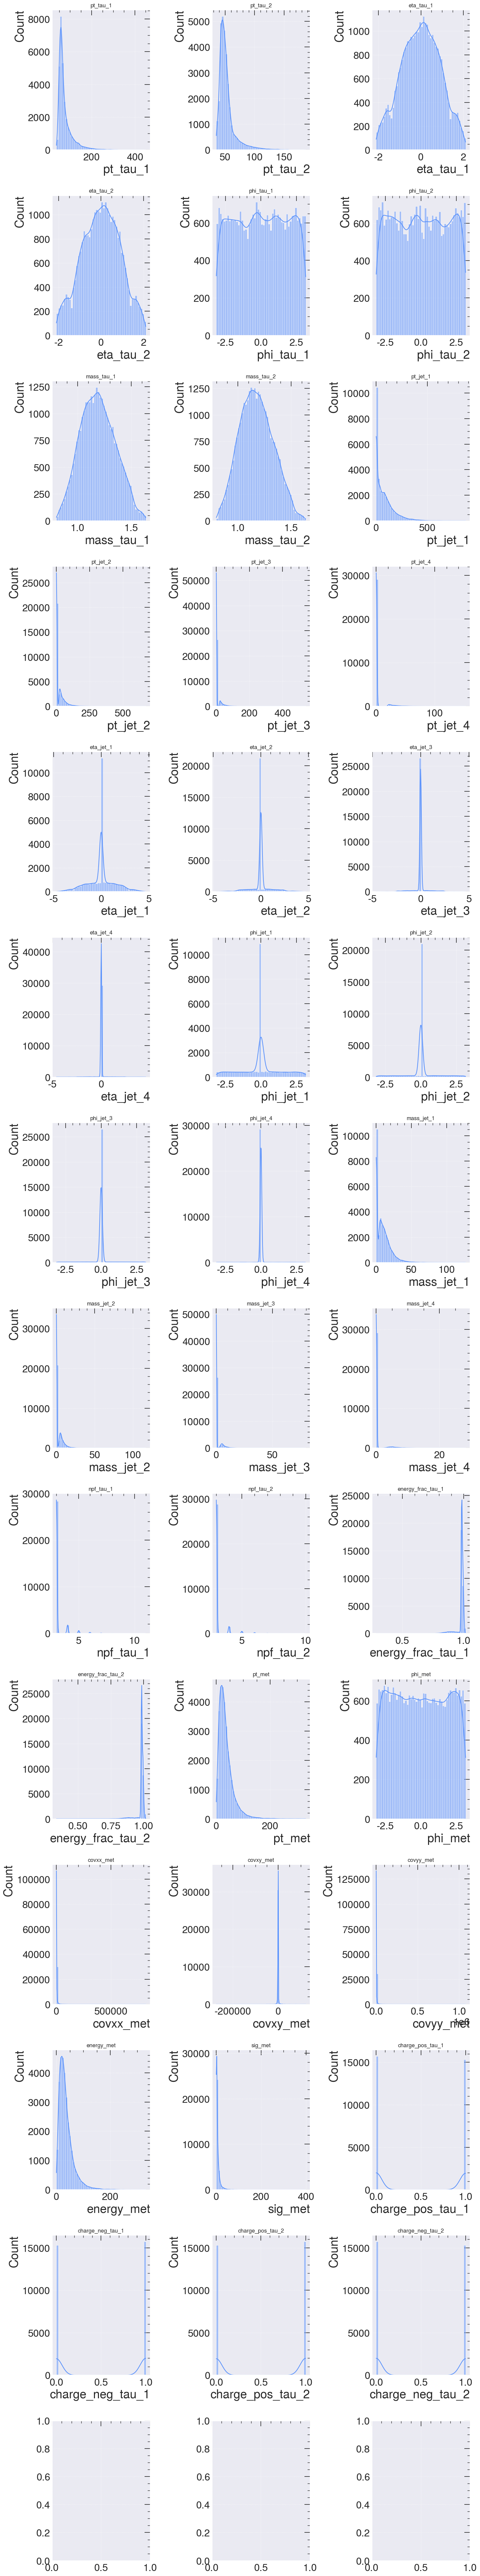

In [134]:
# plt.figure(figsize=(30,24))
# for idx in range(y_train.shape[-1]):
#     # name of the target
#     key = target_keys[idx]
#     print(key)
#     idx=idx+1
#     ax = plt.subplot(2,3,idx)
#     arr_train = y_train[:,idx-1:idx].reshape(-1)
#     arr_test  = y_test [:,idx-1:idx].reshape(-1)

#     #print(arr)
#     minmax = [-50,50] if idx < 7 else [-1,1]
#     ax.hist(arr_train, 100, histtype="stepfilled", alpha=0.7, label='Train', log=False, density=True)
#     ax.hist(arr_test,  100, histtype="stepfilled", alpha=0.7, label='Test',  log=False, density=True)
#     ax.set_title(f"{key}")
#     ax.legend()
# plt.tight_layout()
# plt.savefig(os.path.join(tagdir,f'target_{df_tag_}.png'), dpi=300)
# plt.show()


num_features = len(df_train_x.columns)
fig, axes = plt.subplots(nrows=num_features // 3 + 1, ncols=3, figsize=(15, num_features * 2))
axes = axes.flatten()

for i, col in enumerate(df_train_x.columns):
    sns.histplot(df_train_x[col], bins=50, ax=axes[i], kde=True)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

pt_tau_1
pt_tau_2
eta_tau_1
eta_tau_2
phi_tau_1
phi_tau_2
mass_tau_1
mass_tau_2
pt_jet_1
pt_jet_2
pt_jet_3
pt_jet_4
eta_jet_1
eta_jet_2
eta_jet_3
eta_jet_4
phi_jet_1
phi_jet_2
phi_jet_3
phi_jet_4
mass_jet_1
mass_jet_2
mass_jet_3
mass_jet_4
npf_tau_1
npf_tau_2
energy_frac_tau_1
energy_frac_tau_2
pt_met
phi_met
covxx_met
covxy_met
covyy_met
energy_met
sig_met
charge_pos_tau_1
charge_neg_tau_1
charge_pos_tau_2
charge_neg_tau_2


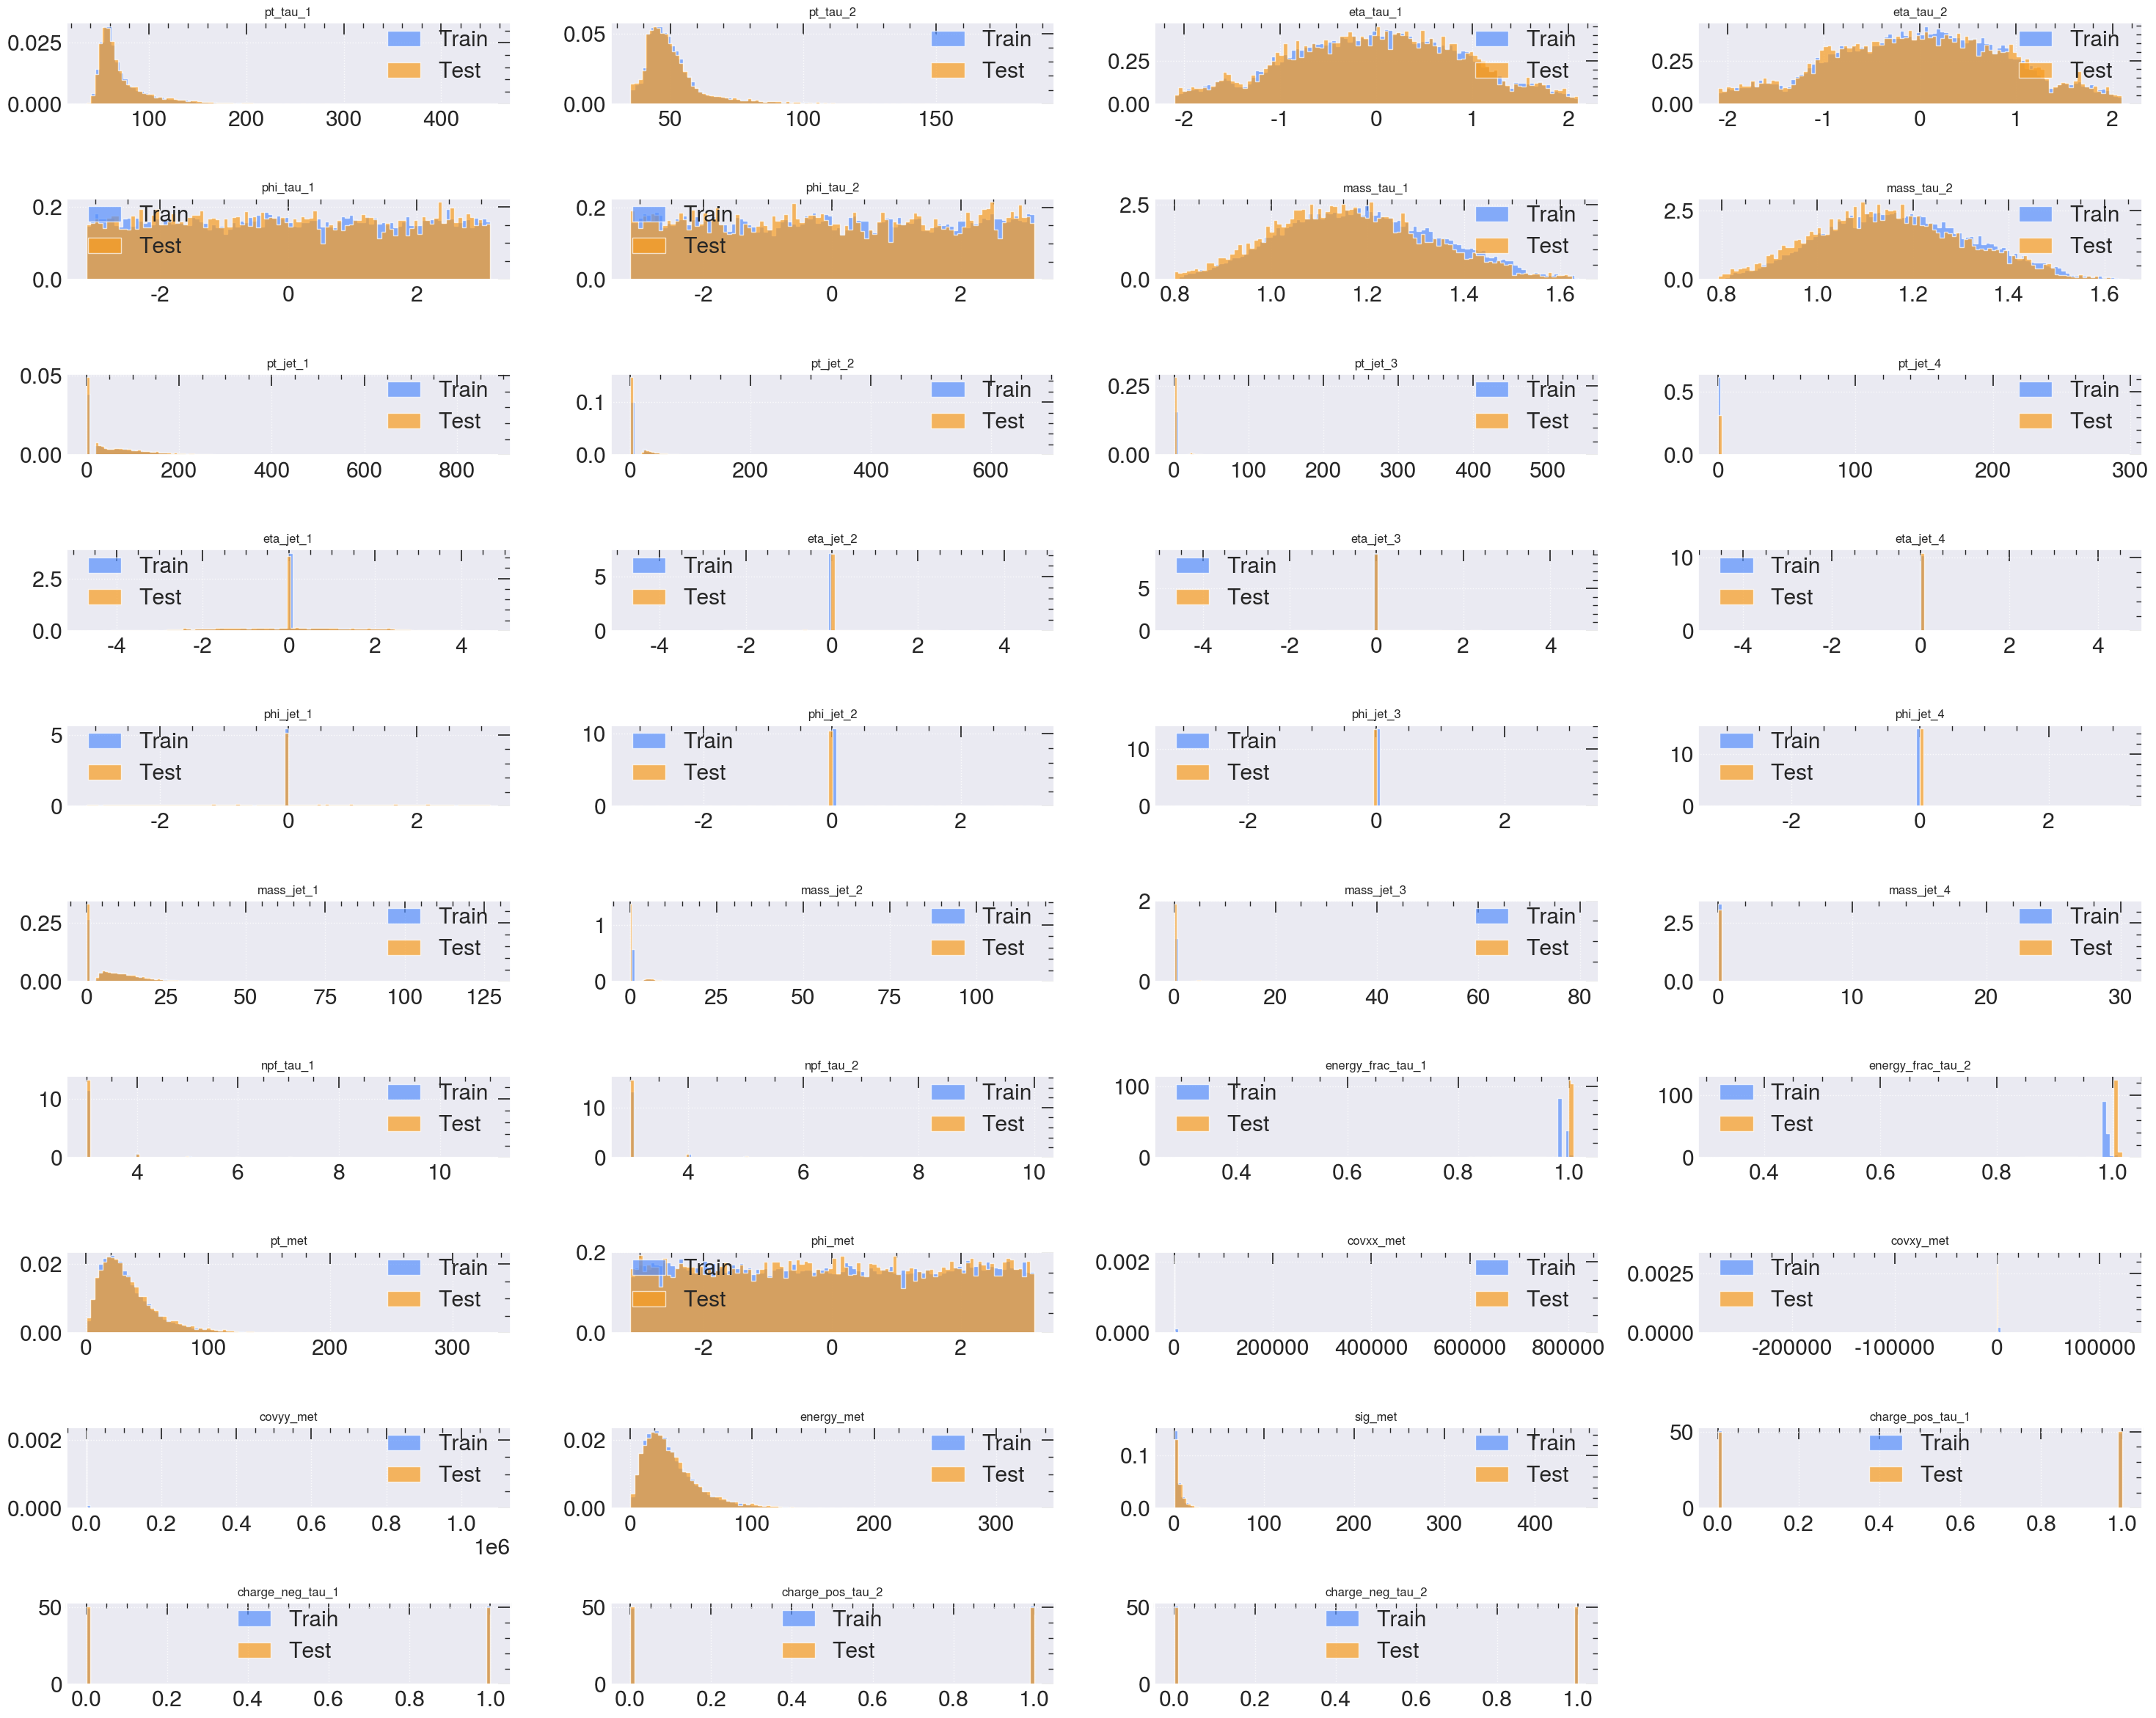

In [140]:
plt.figure(figsize=(30,24))
for idx in range(x_train.shape[-1]):
    # name of the target
    idx=idx+1
    key = df_train_x.keys()[idx-1]   
    print(key) 
    # Number of input var N 
    ax = plt.subplot(10,4,idx)
    arr_train = x_train[:,idx-1:idx].reshape(-1)
    arr_test  = x_test [:,idx-1:idx].reshape(-1)

    #print(arr)
    minmax = [-50,50] if idx < 7 else [-1,1]
    ax.hist(arr_train, 100, histtype="stepfilled", alpha=0.7, label='Train', log=False, density=True)
    ax.hist(arr_test,  100, histtype="stepfilled", alpha=0.7, label='Test',  log=False, density=True)
    ax.set_title(f"{key}")
    ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(tagdir,f'target_{df_tag_}.png'), dpi=300)
plt.show()

### Normalise targets

In [141]:
scaler_y = None

scaler_y = preprocessing.StandardScaler()
scale_data = scaler_y.fit(y_train)

y_train = scaler_y.transform(y_train)
y_test  = scaler_y.transform(y_test)
#y_eval  = scaler_y.transform(y_eval)

print(scaler_y)


StandardScaler()


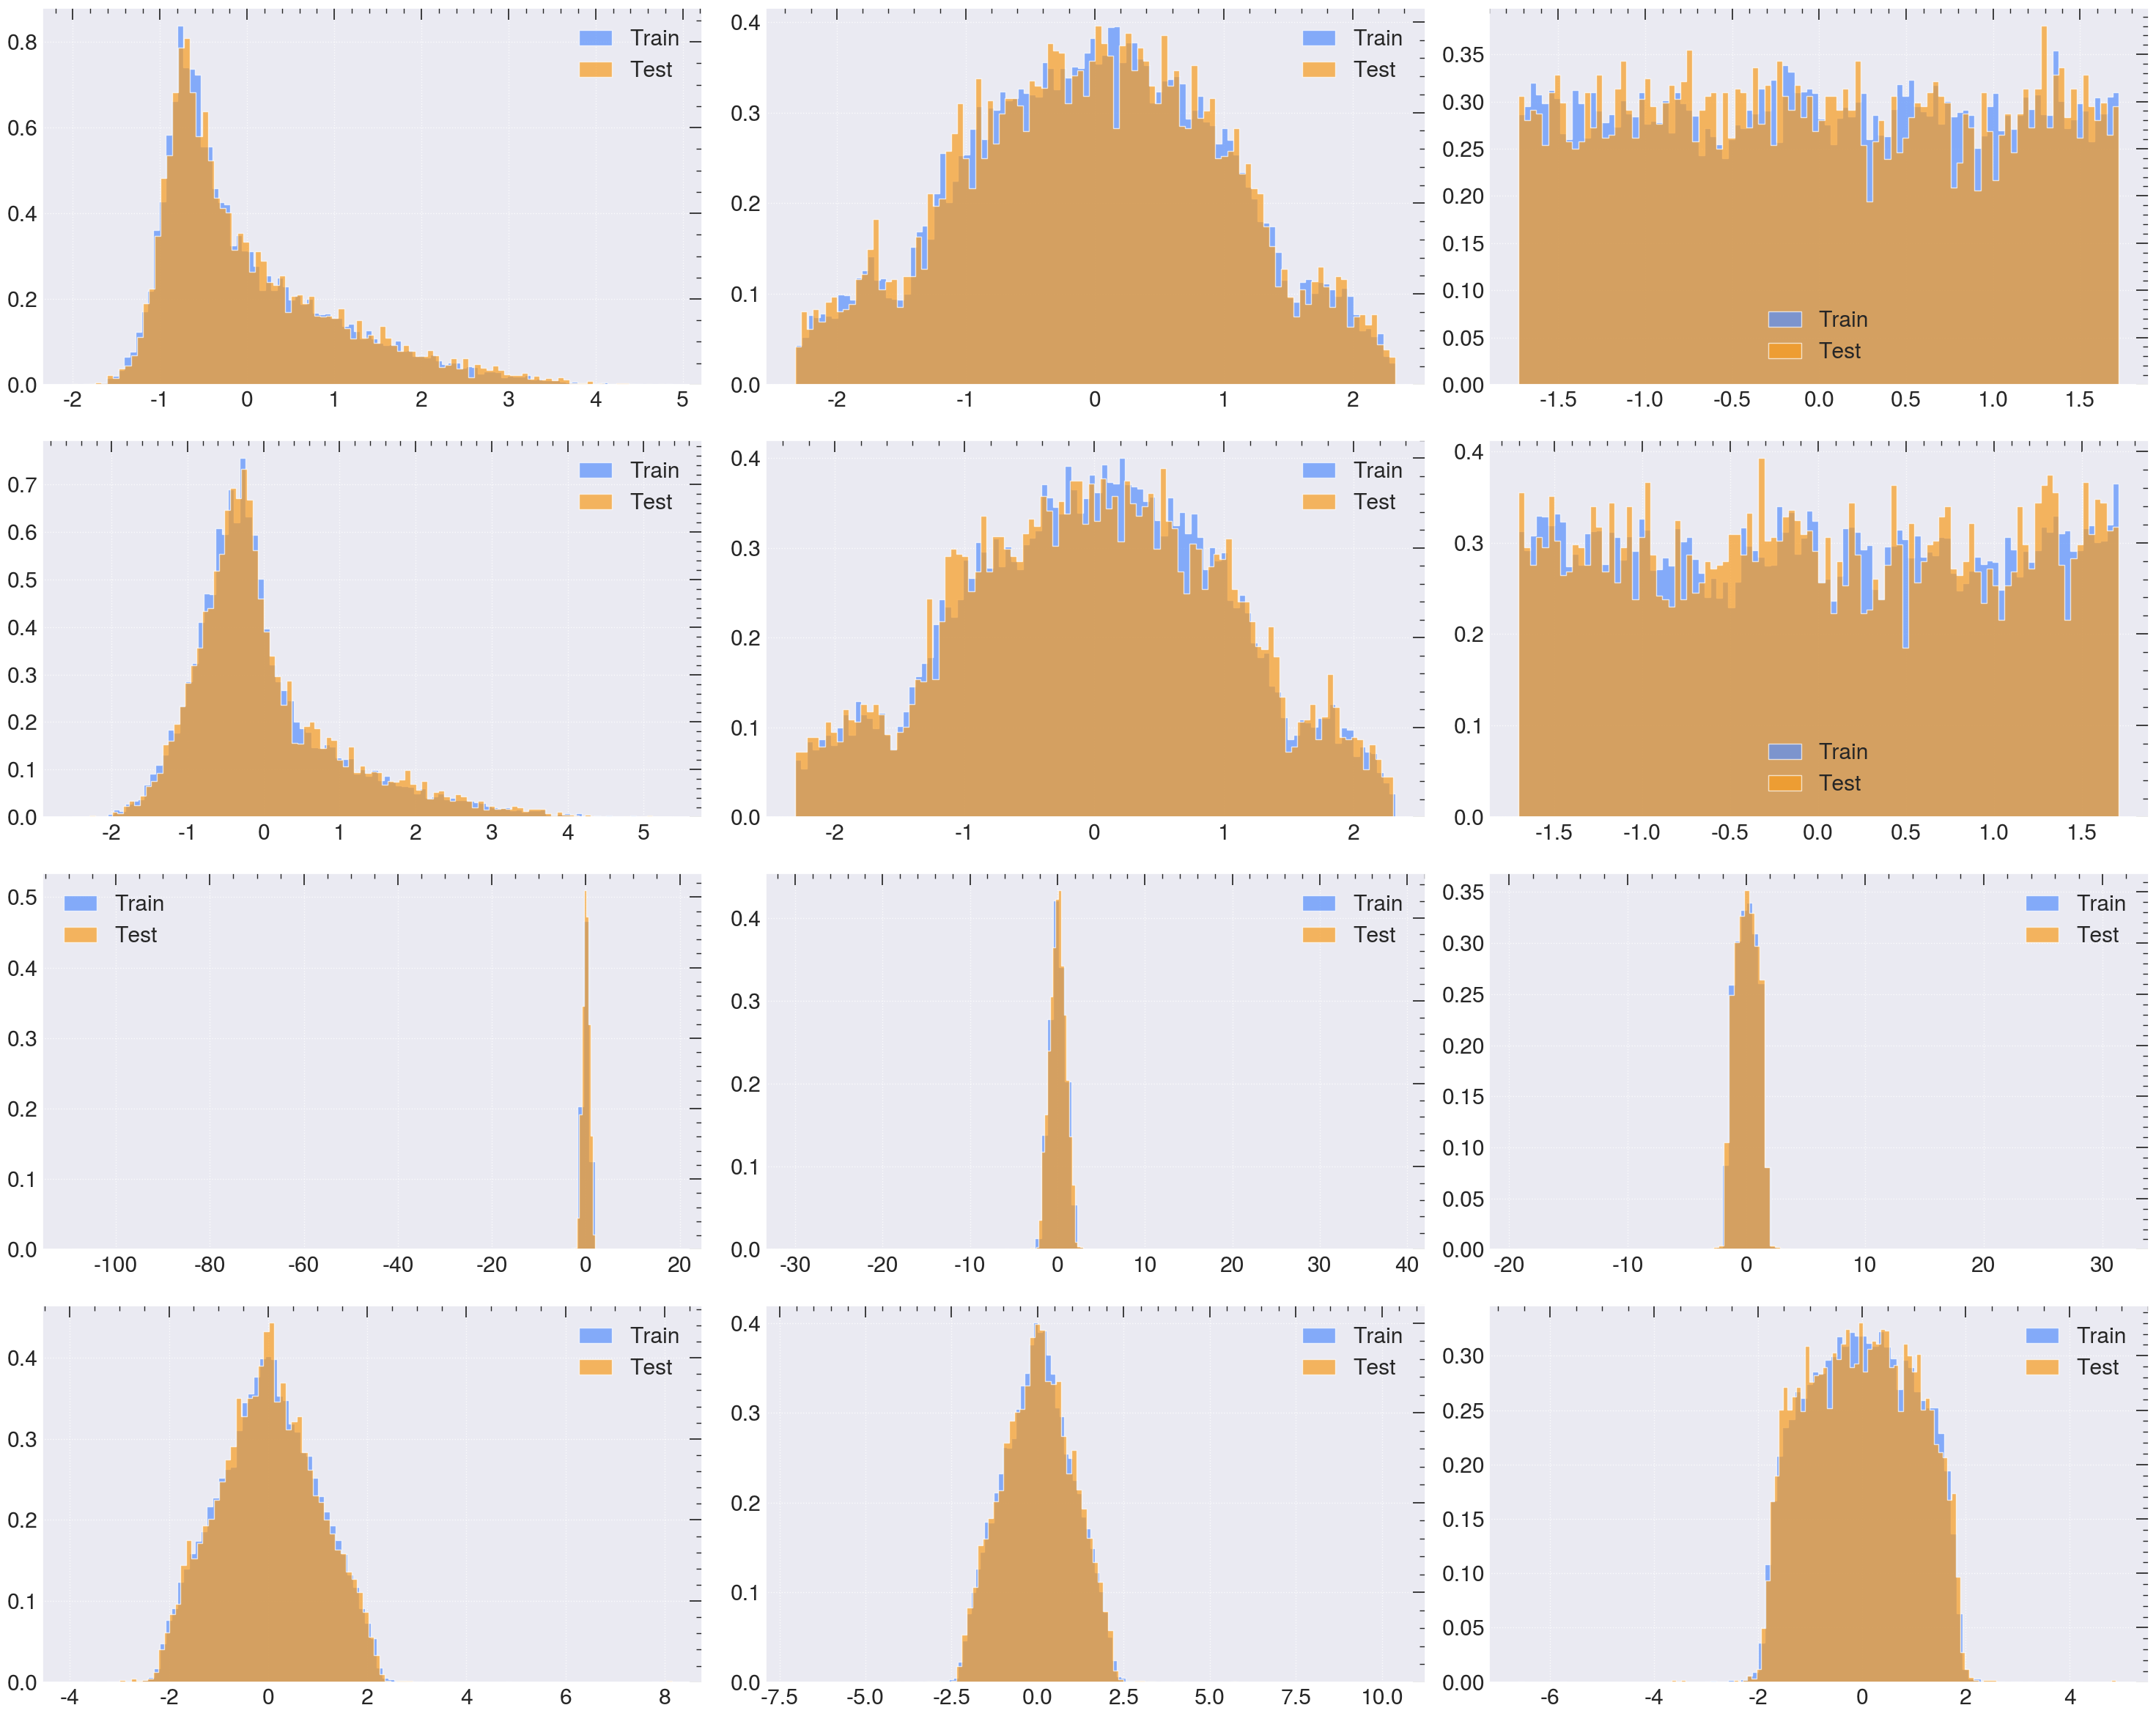

In [142]:

plt.figure(figsize=(30,24))
for idx in range(y_train.shape[-1]):
    idx=idx+1
    ax = plt.subplot(4,3,idx)
    arr_train = y_train[:,(idx-1):idx].reshape(-1)
    arr_test  = y_test [:,(idx-1):idx].reshape(-1)

    #print(arr)
    minmax = [-3,3] if idx < 7 else [-1,1]
    ax.hist(arr_train, 100, histtype="stepfilled", alpha=0.7, label='Train', log=False, density=True)
    ax.hist(arr_test,  100, histtype="stepfilled", alpha=0.7, label='Test',  log=False, density=True)
    ax.legend()
plt.tight_layout()
#plt.savefig(os.path.join(tagdir,f'output_test_{df_tag_}.png'), dpi=300)
plt.show()


In [143]:
features = list(df_train_x.keys())
print(len(features))
targets = list(df_train_y.keys())
print(len(targets))

39
12


In [144]:
inputs_all = []
for feat in feats:
    # print(feat)
    input_layer = Input(shape=(1,), name=feat)
    # print(input_layer)
    inputs_all.append(input_layer)
print(inputs_all)
#print(len(inputs_all))
#print(inputs_all[1].shape)

all_features = tensorflow.keras.layers.concatenate(inputs_all,axis=-1,name="Features")

[<KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=px_tau_1>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=py_tau_1>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=pz_tau_1>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=E_tau_1>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=px_tau_2>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=py_tau_2>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=pz_tau_2>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=E_tau_2>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=px_jet_1>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=py_jet_1>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=pz_jet_1>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=E_jet_1>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=px_jet_2>, <KerasTensor shape=(None, 1), dtype=floa

In [145]:
all_features

<KerasTensor shape=(None, 67), dtype=float32, sparse=False, name=keras_tensor_67>

In [146]:
all_features[0][-1]

<KerasTensor shape=(), dtype=float32, sparse=False, name=keras_tensor_69>

In [147]:
def buildmodel_DNN(input_layers, features):
    """
    Builds a Deep Neural Network (DNN) model with multiple fully connected layers.

    The model includes the following components:
    - Dense layers with decreasing numbers of neurons (512, 256, 128, 64, 32).
    - SELU (Scaled Exponential Linear Unit) activation function for all hidden layers.
    - L2 regularization applied to all layers to reduce overfitting.
    - BatchNormalization to stabilize training and improve convergence.
    - Dropout layers with a 10% rate to prevent overfitting.
    - The final output layer has 7 units (useful for multi-class classification or regression).

    Parameters:
    -----------
    input_layers : Keras Input Layer
        The input layer of the model, representing the input features.
        
    features : ndarray or DataFrame
        The feature data passed through the model, used to determine input shape.

    Returns:
    --------
    model : keras.Model
        A compiled Keras model ready for training.
    """
    print("Building a DNN model")
    # fully connected layers with 512 neurons, selu activation function (scale exponential linear unit)
    #  L2 regularization with a factor of 0.001 
    x = Dense(512, input_dim=features.shape[-1], activation='selu',
              kernel_regularizer=regularizers.l2(0.001))(features) 
    x = BatchNormalization()(x)
    x = Dropout(0.1)(x)
    x = Dense(256, activation='selu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.1)(x)
    x = Dense(128, activation='selu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.1)(x)
    x = Dense(64, activation='selu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.1)(x)
    x = Dense(32, activation='selu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.1)(x)
    x = Dense(12)(x)

    model_inputs = input_layers
    
    model = Model(inputs=model_inputs, outputs=[x])

    return model


In [148]:
def identity_block(X, layerinfo):
    """
    Implements a residual identity block with fully connected (Dense) layers.
    
    This block follows the residual learning approach where the input (X) is 
    passed through multiple Dense layers and then added back to itself via a skip connection.
    
    Parameters:
    -----------
    X : tensor
        Input tensor to the identity block.
    layerinfo : list of int
        A list specifying the number of neurons for each Dense layer in the block.

    Returns:
    --------
    X : tensor
        Output tensor after passing through the identity block.

    Notes:
    ------
    - Uses L2 regularization (0.001) on Dense layers to prevent overfitting.
    - Employs SELU activation for better self-normalizing properties.
    - BatchNormalization is applied after each Dense layer for stable training.
    - A residual connection (Add operation) helps in gradient flow and reduces vanishing gradient issues.
    """
    X_shortcut = X
    for i, nodes in enumerate(layerinfo):
        X = Dense(nodes, kernel_regularizer=regularizers.l2(0.001))(X)
        X = Activation('selu')(X)
        X = BatchNormalization()(X)

    X = Add()([X, X_shortcut])
    X = Activation('selu')(X)

    return X

def conv_block(X, layerinfo):
    X_shortcut = X
    for i, nodes in enumerate(layerinfo):
        X = Dense(nodes, activation='selu', kernel_regularizer=regularizers.l2(0.0001))(X)
        #X = Activation('selu')(X)
        #X = BatchNormalization()(X)

    #X_shortcut = Dense(layerinfo[-1])(X)
    X_shortcut = Dense(layerinfo[-1])(X_shortcut)
    #X_shortcut = BatchNormalization()(X_shortcut)
    X = Add()([X, X_shortcut])
    X = Activation('selu')(X)
    X = BatchNormalization()(X)

    return X

def buildmodel_Resnet(input_layers, features):
    print("Building a SkipNetwork DNN model")
    X = Dense(512, input_dim=features.shape[-1], activation='selu',
              kernel_regularizer=regularizers.l2(0.0001))(features)
    X = BatchNormalization()(X)
    X = Dropout(0.1)(X)

    X = conv_block(X, [512, 512, 512])
    X = Dropout(0.1)(X)
    X = conv_block(X, [256, 256, 256])
    X = Dropout(0.1)(X)
    X = conv_block(X, [128, 128, 128])
    X = Dropout(0.1)(X)
    X = conv_block(X, [64, 64, 64])
    X = Dropout(0.1)(X)
    X = Dense(7)(X)


    model_inputs = [input_layers]
    print(f"model_inputs: {model_inputs}")
    model = Model(inputs=model_inputs, outputs=[X])

    return model

In [211]:
import tensorflow as tf

class child_LBNLayer(LBNLayer):
    """
    A subclass of LBNLayer that avoids the parent_path issue.
    """

    def __init__(self, input_shape, *args, **kwargs):
        # Remove 'dynamic' from kwargs if it is present, as it isn't needed by LBNLayer
        kwargs.pop('dynamic', None)

        # Initialize the parent (LBNLayer) with the cleaned-up kwargs
        super(BLNLayer, self).__init__(input_shape, *args, **kwargs)

    def build(self, input_shape):
        """
        Build the layer by calling the parent class's build method.
        """
        # Call the parent class's build method
        super(BLNLayer, self).build(input_shape)

    def call(self, inputs):
        """
        Forward pass: Use the LBN (or inherited) logic to process the input.
        """
        return super(BLNLayer, self).call(inputs)

    def compute_output_shape(self, input_shape):
        """
        Compute the output shape using the parent class's method.
        """
        return super(BLNLayer, self).compute_output_shape(input_shape)

    def get_config(self):
        """
        Get the configuration of this layer, using the parent class's configuration.
        """
        config = super(BLNLayer, self).get_config()
        config.update({
            "layer_name": self.name,  # Optionally, include additional custom fields
        })
        return config


In [260]:
class Custom_LBNLayer(tf.keras.layers.Layer):
    """
    Keras 3 compatible custom layer for Lorentz Boost Network (LBN).
    """

    def __init__(self, n_particles, boost_mode, features=None, external_features=None, **kwargs):
        super().__init__(**kwargs)

        # Store LBN parameters
        self.n_particles = n_particles
        self.boost_mode = boost_mode
        self.features = features
        self.external_features = external_features

        # Initialize the LBN instance
        self.lbn = LBN(n_particles=n_particles, boost_mode=boost_mode)

    def build(self, input_shape):
        """Builds the LBN layer."""
        self.lbn.build(input_shape, features=self.features, external_features=self.external_features)

        # Store references to trainable weights
        self.particle_weights = self.lbn.particle_weights
        self.restframe_weights = self.lbn.restframe_weights
        self.aux_weights = self.lbn.aux_weights

        super().build(input_shape)

    def call(self, inputs, training=False):
        """Forward pass through the LBN layer."""
        return self.lbn(inputs)

    def compute_output_shape(self, input_shape):
        return (input_shape[0], self.lbn.n_features)

    def get_config(self):
        """Returns the configuration of the layer for serialization."""
        config = super().get_config()
        config.update({
            "n_particles": self.n_particles,
            "boost_mode": self.boost_mode,
            "features": self.features,
            "external_features": self.external_features,
        })
        return config

In [273]:
from lbn import LBN, LBNLayer
def buildmodel_LBN(inputs_all, x_train_LBN, all_features):
    """
    Builds a deep learning model incorporating a Lorentz Boost Network (LBN) layer.

    The Lorentz Boost Network (LBN) extracts Lorentz-invariant features from raw particle kinematics. 

    This model processes both:
    1. Standard input features (`inputs_all`)
    2. LBN-transformed features (`x_train_LBN`)
    
    The extracted LBN features are concatenated with additional features and passed through 
    a fully connected deep neural network (DNN).

    Parameters:
    -----------
    inputs_all : tensor
        The primary input tensor containing additional event-level features beyond the LBN representation.
    x_train_LBN : numpy array
        Training data for the LBN layer, used to determine input shape.
    all_features : tensor
        Additional feature tensor to be concatenated with the LBN output.

    Returns:
    --------
    model : tensorflow.keras.Model
        A compiled model that takes in both raw inputs and LBN-transformed inputs.
    lbn_layer : tensor
        The output tensor of the LBN layer, useful for inspecting feature transformations.

    LBN Layer Details:
    ------------------
    - `n_particles=25`: Selects 25 particles per event for feature extraction.
    - `boost_mode=LBN.PAIRS`: Computes **pairwise Lorentz-invariant features** (e.g., mass, angular distances).
    - `features=["E", "px", "py", "pz", "pt", "p", "phi", "eta", "m", "pair_cos"]`: 
      Specifies extracted physics features.

    Architecture:
    -------------
    1. **LBN Layer:** Extracts physics-informed features.
    2. **Batch Normalization:** Normalizes the LBN output for stability.
    3. **Concatenation:** Merges the LBN output with additional input features.
    4. **Fully Connected Layers:** A deep neural network with SELU activations, batch normalization, and dropout.
    5. **Output Layer:** A final dense layer with 6 output neurons.

    Notes:
    ------
    - Uses **L2 regularization** (0.001) on Dense layers to prevent overfitting.
    - Employs **SELU activation** for self-normalizing behavior.
    - Batch normalization ensures stable training.
    - The model outputs a tensor of size **6**, which could correspond to a classification or regression task.

    """
    print("Building a LBN model")
    # Define the input layer = tensor for Kera Model 
    input_lbn_Layer = tensorflow.keras.Input(shape=x_train_LBN.shape[1:],name='LBN_inputs')
    print(f'type & shape of lbn input: {type(input_lbn_Layer)}, {input_lbn_Layer.shape}')

    
    lbn_layer = Custom_LBNLayer(n_particles=25, boost_mode="pairs", 
                      features=["E", "px", "py", "pz", "pt", "p", "phi", "eta", "m", "pair_cos"])

    print("lbn_layer : ", lbn_layer)

    print("input_lbn_Layer : ", input_lbn_Layer)

    lbn_layer = lbn_layer(input_lbn_Layer)


    # lbn_layer = child_LBNLayer(input_shape=x_train_LBN.shape[1:], n_particles=25, boost_mode=LBN.PAIRS)

    # # Define the LBN layer
    # lbn_layer = LBNLayer(input_shape=x_train_LBN.shape[1:],
    #                      n_particles = 25,
    #                      boost_mode  = LBN.PAIRS,
    #                      features    = ["E", "px", "py", "pz", "pt", "p", "phi","eta", "m", "pair_cos"],
    #                      #features    = ["E","px","py","pz","pt","p","m","phi","eta","beta","gamma","pair_cos","pair_dr","pair_ds","pair_dy"],
    #                      name='LBN')(input_lbn_Layer)



    print(f'Type & shape of LBN layer : {type(lbn_layer)}')

    batchnorm = tensorflow.keras.layers.BatchNormalization(name='batchnorm')(lbn_layer)
    print(f'type & shape of batchnorm : {type(batchnorm)}, {batchnorm.shape}')

    concat = tensorflow.keras.layers.Concatenate(axis=-1)([all_features, batchnorm])
    print(f'Concatenated shape : {concat.shape}')
    print(f'Concatenated type  : {type(concat)}')


    x = Dense(512, activation='selu', kernel_regularizer=regularizers.l2(0.001))(concat)
    x = BatchNormalization()(x)
    x = Dropout(0.1)(x)
    x = Dense(256, activation='selu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.1)(x)
    x = Dense(128, activation='selu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.1)(x)
    x = Dense(64, activation='selu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.1)(x)
    x = Dense(12)(x)

    model_inputs = [inputs_all]
    model_inputs.append(input_lbn_Layer)
    print(model_inputs)
    model = Model(inputs=model_inputs, outputs=[x])

    return model, lbn_layer

In [258]:

def buildmodel_LBN_ResNet(inputs_all, 
                          x_train_LBN, 
                          all_features, 
                          n_particles=n_particles,
                          lbn_feat_names=lbn_feat_names):
    logger.info("Building a LBN with skip connection model") 
    input_lbn_Layer = tensorflow.keras.Input(shape=x_train_LBN.shape[1:],name='LBN_inputs')
    logger.info(f'type & shape of lbn input: {type(input_lbn_Layer)}, {input_lbn_Layer.shape}')

    lbn_layer = LBNLayer(x_train_LBN.shape[1:],
                         n_particles = n_particles,
                         boost_mode  = LBN.PAIRS,
                         features    = lbn_feat_names,
                         #features    = ["E","px","py","pz","pt","p","m","phi","eta","beta","gamma","pair_cos","pair_dr","pair_ds","pair_dy"],
                         name='LBN')(input_lbn_Layer)
    
    
    logger.info(f'Type & shape of LBN layer : {type(lbn_layer)}')


    batchnorm = tensorflow.keras.layers.BatchNormalization(name='batchnorm')(lbn_layer)
    logger.info(f'type & shape of batchnorm : {type(batchnorm)}, {batchnorm.shape}')

    concat = tensorflow.keras.layers.Concatenate(axis=-1)([all_features, batchnorm])
    logger.info(f'Concatenated shape : {concat.shape}')
    logger.info(f'Concatenated type  : {type(concat)}')


    #x = Dense(512, activation='selu', kernel_regularizer=regularizers.l2(0.001))(concat)
    #x = BatchNormalization()(x)
    #x = Dropout(0.1)(x)

    #x = conv_block(concat, [1024, 1024, 1024])
    #x = Dropout(0.1)(x)
    x = conv_block(concat, [512, 512, 512])
    #x = conv_block(x, [512, 512, 512])
    x = Dropout(0.1)(x)
    x = conv_block(x, [256, 256, 256])
    x = Dropout(0.1)(x)
    x = conv_block(x, [256, 256, 256])
    x = Dropout(0.1)(x)
    x = conv_block(x, [128, 128, 128])
    x = Dropout(0.1)(x)
    x = conv_block(x, [64, 64, 64])
    x = Dropout(0.1)(x)
    x = Dense(12)(x)
    # x = Dense(6)(x) 
    

    model_inputs = [inputs_all]
    model_inputs.append(input_lbn_Layer)
    logger.info(f"model_inputs : {model_inputs}")
    model = Model(inputs=model_inputs, outputs=[x])

    return model, lbn_layer

In [271]:
def getmodel(input_layers=inputs_all, x_train_LBN=x_train_LBN, features=all_features, tag=tag_):
    model = None
    lbn_out = None

    print(input_layers)
    print(input_layers[0].shape)
    tag_split = tag_.split('_')[0]
    if tag_split=="DNN":
        model = buildmodel_DNN(input_layers, features)
    elif tag_split=="LBN":
        # print("Run LBN")
        # print("inputs all: ", input_layers)
        # print("x_train_LBN: ", x_train_LBN)
        # print("features: ", features)   
        model = buildmodel_LBN(input_layers, x_train_LBN, features)
    elif tag_split=="ResNet":
        model = buildmodel_Resnet(input_layers, features)
    elif tag_split=="LBNResNet":
        model, lbn_out = buildmodel_LBN_ResNet(input_layers, x_train_LBN, features)
    else:
        print("Run DNN as no tag mentioned")
        model = buildmodel_DNN(input_layers, features)

    return model

In [272]:
model = getmodel(tag=tag_)
print("len of model inputs:", len(model.inputs))

logger.info(model.summary())

# print model Features 
model_features = model.get_config()
# print(model_features)

[<KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=px_tau_1>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=py_tau_1>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=pz_tau_1>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=E_tau_1>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=px_tau_2>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=py_tau_2>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=pz_tau_2>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=E_tau_2>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=px_jet_1>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=py_jet_1>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=pz_jet_1>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=E_jet_1>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=px_jet_2>, <KerasTensor shape=(None, 1), dtype=floa

ValueError: Exception encountered when calling Custom_LBNLayer.call().

[1mCannot convert '(None, 525.0)' to a shape. Found invalid entry '525.0' of type '<class 'float'>'. [0m

Arguments received by Custom_LBNLayer.call():
  • args=('<KerasTensor shape=(None, 7, 4), dtype=float32, sparse=None, name=LBN_inputs>',)
  • kwargs={'training': 'False'}

In [91]:
# Compile and fit
#set early stopping monitor so the model stops training when it won't improve anymore                                                                     
#early_stopping_monitor = EarlyStopping(patience=3)                                                                                                       
# https://towardsdatascience.com/a-practical-introduction-to-early-stopping-in-machine-learning-550ac88bc8fd                                              
custom_early_stopping = EarlyStopping(
    monitor='val_loss',
    #monitor='loss',
    #patience=int(nEpoch/10),
    patience=20,                                                                                                                                         
    min_delta=0.001,
    verbose=1,
    restore_best_weights=True,
    #restore_best_weights=False,                                                                                                                          
    mode='min',
    #mode='max'                                                                                                                                         
)
#https://keras.io/api/callbacks/reduce_lr_on_plateau/                                                                                                     
custom_ReduceLROnPlateau = ReduceLROnPlateau(
    monitor="val_loss",
    #monitor="loss",                                                                                                                  
    factor=0.5, #0.1
    #patience=5,                                                                                                                                          
    patience=10,
    verbose=1,
    mode="min",
    #mode="max",                                                                                                                                          
    cooldown=0,                                                                                                                                          
    #cooldown=5,
    #min_lr=0
    min_lr=1e-10,                                                                                                                                         
    min_delta=0.0001                                                                                                                                      
)

def lr_schedule(epoch):
    if epoch < 5:
        return 1e-5 + (epoch / 5) * 0.001  # Gradual warmup
    return 0.001 * (0.1 ** (epoch // 20))  # Then decay

lr_warmup = tf.keras.callbacks.LearningRateScheduler(lr_schedule)



#custom loss-history with batch
#https://github.com/cp3-llbb/HHbbWWAnalysis/blob/master/MachineLearning/HHMachineLearning/Model.py#L47
class LossHistory(Callback):
    """ Records the history of the training per epoch and per batch """
    def on_train_begin(self, logs={}):
        self.epochs  = defaultdict(list) 
        self.batches = defaultdict(list) 
        self.pre_batch = 0

    def on_batch_end(self, batch, logs={}):
        self.batches['batch'].append(batch+self.pre_batch)
        for key,val in logs.items():
            self.batches[key].append(val)
        # self.batches['lr'].append(tensorflow.keras.backend.eval(self.model.optimizer.lr))
        # Get current learning rate and store it
        current_lr = self.model.optimizer.learning_rate.numpy()  # Correct access to learning rate
        self.batches['lr'].append(current_lr)
        #loss = logs.get('loss')
        #print(f'\nBatch : {batch} with average loss : {loss}')

    def on_epoch_end(self, epoch, logs={}):
        self.epochs['epoch'].append(epoch)
        for key,val in logs.items():
            self.epochs[key].append(val)
        #self.epochs['lr'].append(tensorflow.keras.backend.eval(self.model.optimizer.lr))
        current_lr = self.model.optimizer.learning_rate.numpy() 
        self.epochs['lr'].append(current_lr)
        self.pre_batch = self.batches['batch'][-1] 

    def plot(self):
        # Function to plot loss curves (optional)
        import matplotlib.pyplot as plt
        plt.plot(self.epochs['epoch'], self.epochs['loss'], label='Training Loss')
        if 'val_loss' in self.epochs:
            plt.plot(self.epochs['epoch'], self.epochs['val_loss'], label='Validation Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.title('Training and Validation Loss')
        plt.show()

In [92]:
#print(x_train.shape)
#fit_inputs = np.hsplit(x_train,x_train.shape[1])
#print(len(fit_inputs))

x_train = LBN_dict['x_train'] if "LBN" in tag_ else x_train
x_test  = LBN_dict['x_test'] if "LBN" in tag_ else x_test
#x_train = x_train_DNN if tag_=="LBN" else x_train
#x_test  = x_test_DNN if tag_=="LBN" else x_test


print(x_train.shape)
fit_inputs = np.hsplit(x_train, x_train.shape[1])
print(len(fit_inputs))
if "LBN" in tag_:
    fit_inputs.append(x_train_LBN)

print(len(fit_inputs))
print(fit_inputs[0].shape)
print(fit_inputs[-1].shape)


fit_tests = np.hsplit(x_test, x_test.shape[1])
if "LBN" in tag_:
    fit_tests.append(x_test_LBN)


(31021, 39)
39
39
(31021, 1)
(31021, 1)


In [93]:
def huber_loss_(threshold=1.0):  
    def loss(y_true, y_pred):
        error = y_true - y_pred
        is_small_error = tf.abs(error) <= threshold     
        small_error_loss = tf.square(error) / 2  # Quadratic for small errors
        big_error_loss = threshold * (tf.abs(error) - (0.5 * threshold))  # Linear for large errors
        return tf.where(is_small_error, small_error_loss, big_error_loss)
    
    return loss

In [94]:
def custom_loss():
    
    def loss(y_true, y_pred):
        print(f"y_true: {y_true}")
        print(f"y_pred: {y_pred}")
        #lbn_input = np.array(x_input[-1])
        #print(f"x_input: {lbn_input.shape}")
        #print("Check y in detail")
        print(y_true[:,:1], y_pred[:,:1])
        print(y_true[:,1:2], y_pred[:,1:2])
        print(y_true[:,2:3], y_pred[:,2:3])
        #x = tf.convert_to_tensor(x_input)
        #print(f'x: {x[:,:1]}')
        se = tf.square(y_true[:,:-1]-y_pred[:,:-1])
        #mse = tf.reduce_mean(se)
        mass = tf.square(y_true[:,-1:] - y_pred[:,-1:])
        #mass = tf.reduce_mean(mass)
        #mse = tf.cast(mse, tf.float64)
        # print(f"mse: {mse}")
        return tf.reduce_mean(tf.add(se,mass))
        #return tf.add(mse, mass)
    return loss


def huber_loss(y_true, y_pred, threshold):
    error = y_true - y_pred
    is_small_error = tf.abs(error) <= threshold     
    small_error_loss = tf.square(error) / 2     
    big_error_loss = threshold * (tf.abs(error) - (0.5 * threshold))
    loss = tf.where(is_small_error, small_error_loss, big_error_loss)
    #mean_loss = tf.reduce_mean(loss)
    #print(f"Loss: {loss}")
    return loss

def custom_loss_2(threshold=1.0, beta=2.0):
    def huber_loss_mean(y_true, y_pred):
        huber_loss_val = tf.reduce_mean(huber_loss(y_true[:,:-1], y_pred[:,:-1], threshold), 1)
        print(f"huber_loss_val: {huber_loss_val}")
        mass_huber_loss_val = huber_loss(y_true[:,-1], y_pred[:,-1], threshold)
        print(f"mass_huber_loss_val: {mass_huber_loss_val}")
        loss = tf.reduce_mean(tf.add(huber_loss_val, beta*mass_huber_loss_val))  
        return loss
    return huber_loss_mean

def custom_loss_3(alpha=1.0, beta=1.0):
    def comp_loss(y_true, y_pred):
        #mae_loss_val = tf.reduce_sum(tf.abs(y_true[:,:-1] - y_pred[:,:-1]))
        mae_loss_val = alpha*tf.abs(y_true[:,:-1] - y_pred[:,:-1])
        #mae_loss_val = tf.cumsum(mae_loss_val, 1)
        print(f"mae_loss_val: {mae_loss_val}")
        #mass_loss_val = tf.reduce_sum(beta*((y_pred[:,-1]/y_true[:,-1]) - 1))
        mass_loss_val = tf.abs(beta*((y_pred[:,-1]/y_true[:,-1]) - 1))
        print(f"mass_loss_val: {mass_loss_val}")
        loss = tf.concat([mae_loss_val, tf.reshape(mass_loss_val, [-1,1])], 1)
        #loss = tf.reduce_sum(loss)
        loss = tf.reduce_mean(tf.reduce_sum(loss, 1))
        return loss
    return comp_loss

In [95]:
t1 = [[1, 2, 3], [4, 5, 6]]
t1 = tf.reshape(t1, [-1])
t2 = tf.reshape(t1, [-1,1])
t2

<tf.Tensor: shape=(6, 1), dtype=int32, numpy=
array([[1],
       [2],
       [3],
       [4],
       [5],
       [6]], dtype=int32)>

In [96]:

# from tf_keras.optimizers.legacy import Adam
# optimizer = Adam(learning_rate=0.001)

# loss_history = LossHistory()
# #y_pred = model.evaluate()
# #tau1phi = df_train_x["tau_1_phi"].to_numpy()
# #tau1phi = np.abs(tau1phi)
# model.compile(loss=tensorflow.keras.losses.MeanAbsoluteError(),  #tensorflow.keras.losses.Huber(), #custom_loss_3(), #tensorflow.keras.losses.Huber(), custom_loss(fit_inputs), custom_loss(x_train_LBN), custom_loss_1(df_train_x), tensorflow.keras.losses.Huber(), custom_loss_1(tau1phi),
#               optimizer=tensorflow.keras.optimizers.legacy.Adam(learning_rate=0.01),
#               metrics=[tensorflow.keras.metrics.R2Score(),
#                        tensorflow.keras.metrics.MeanAbsoluteError(),
#                        tensorflow.keras.metrics.MeanAbsolutePercentageError()])


# #log_dir = f"{tag_}/logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
# log_dir = f"{tag_}/logs/fit/" + dttag
# tensorboard_callback = tensorflow.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

# #datetime_tag = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
# checkpoint_path = f"{tagdir}/training_{dttag}/cp.ckpt"
# checkpoint_dir = os.path.dirname(checkpoint_path)

# # Create a callback that saves the model's weights
# cp_callback = tensorflow.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
#                                                  save_weights_only=True,
#                                                  verbose=1)

# callback_list = [custom_early_stopping,
#                  custom_ReduceLROnPlateau,
#                  loss_history,
#                  tensorboard_callback,
#                  cp_callback]

import tensorflow as tf
import os

# Assuming dttag and tag_ are defined earlier in the code
log_dir = f"{tag_}/logs/fit/" + dttag
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

checkpoint_path = f"{tagdir}/training_{dttag}/cp.weights.h5"  # Change .ckpt to .weights.h5
checkpoint_dir = os.path.dirname(checkpoint_path)

# Create a callback that saves the model's weights
cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                                 save_weights_only=True,
                                                 verbose=1)
# Updated Optimizer and Metrics for Keras 3.x
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)


# Define the loss history callback
loss_history = LossHistory()

# # Compile the model with updated Keras 3.x components
# model.compile(
#     loss=tf.keras.losses.MeanAbsoluteError(),  # or any other loss function you need
#     optimizer=optimizer,
#     metrics=[
#         # R2Score is not available in Keras 3.x. Implement custom R2Score metric if needed
#         tf.keras.metrics.MeanAbsoluteError(),
#         tf.keras.metrics.MeanAbsolutePercentageError()
#     ]
# )

model.compile(
    loss=huber_loss_(threshold=1.0),  # or any other loss function you need
    optimizer=optimizer,
    metrics=[
        # R2Score is not available in Keras 3.x. Implement custom R2Score metric if needed
        tf.keras.metrics.MeanAbsoluteError(),
        tf.keras.metrics.MeanAbsolutePercentageError()
    ]
)

# Define the callback list
callback_list = [
    custom_early_stopping,
    custom_ReduceLROnPlateau,
    loss_history,
    tensorboard_callback,
    # cp_callback
]

39
Epoch 1/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 129ms/step - loss: 1.3611 - mean_absolute_error: 1.0584 - mean_absolute_percentage_error: 901.9944 - val_loss: 1.2658 - val_mean_absolute_error: 0.9934 - val_mean_absolute_percentage_error: 834.1678 - learning_rate: 0.0010
Epoch 2/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 1.1570 - mean_absolute_error: 0.8830 - mean_absolute_percentage_error: 562.7646 - val_loss: 1.1644 - val_mean_absolute_error: 0.9410 - val_mean_absolute_percentage_error: 595.0315 - learning_rate: 0.0010
Epoch 3/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 1.0690 - mean_absolute_error: 0.8430 - mean_absolute_percentage_error: 599.2509 - val_loss: 1.1111 - val_mean_absolute_error: 0.9461 - val_mean_absolute_percentage_error: 478.8604 - learning_rate: 0.0010
Epoch 4/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.9999 - mean_absolute_error: 0.8258 - mean_absolute_percentage_error: 408.9015 - val_loss: 1.0533 - val_mean_absolute_error: 0.9423 - val_mean_absolute_per

2025-03-17:10:03:17,629 INFO     [1036142202.py:37] Plot saved: /pbs/home/o/oponcet/private/TauRegression/BasicNN/DNN_Higgs_Flat_Feb25/Loss_Acc_LR_events_a1a1_new_nPart_10_executed_on_20250317_095238.png
2025-03-17:10:03:17,629 INFO     [1036142202.py:37] Plot saved: /pbs/home/o/oponcet/private/TauRegression/BasicNN/DNN_Higgs_Flat_Feb25/Loss_Acc_LR_events_a1a1_new_nPart_10_executed_on_20250317_095238.png


variables: ['loss', 'mean_absolute_error', 'mean_absolute_percentage_error', 'lr']
var =  loss
var =  mean_absolute_error
var =  mean_absolute_percentage_error
var =  lr
Curves saved as /pbs/home/o/oponcet/private/TauRegression/BasicNN/DNN_Higgs_Flat_Feb25/Loss_Acc_LR_events_a1a1_new_nPart_10_executed_on_20250317_095238.png


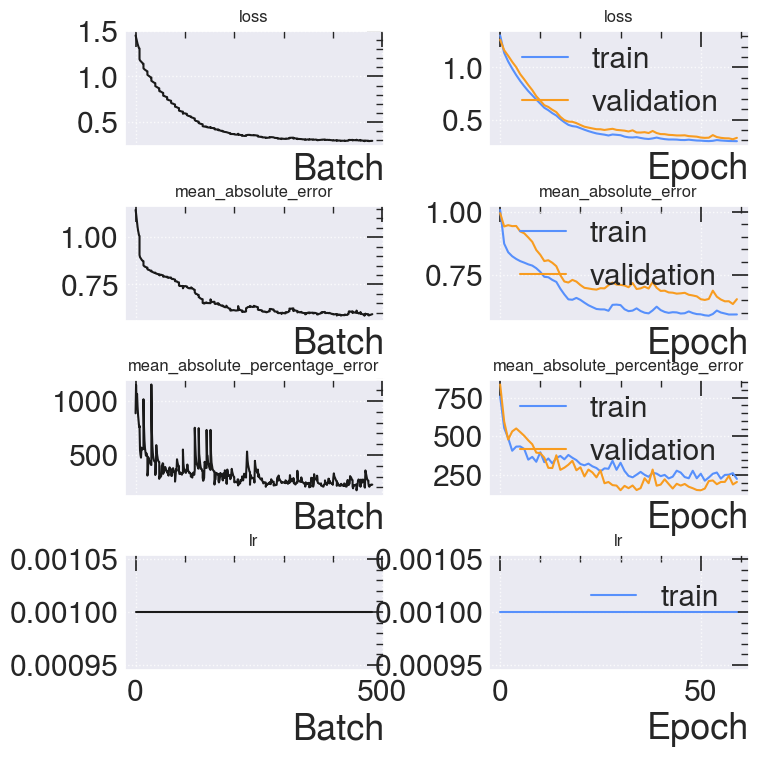

In [97]:
# history = None
# if train:
#     history = model.fit(fit_inputs,
#                         y_train,
#                         epochs=nepochs,
#                         batch_size=3000,
#                         validation_split=0.2,
#                         #sample_weight=wt,
#                         verbose=1,
#                         use_multiprocessing=True,
#                         callbacks=callback_list)
#     PlotHistory(loss_history, path=tagdir)
# else:
#     checkpoint_path = hereismodel
#     checkpoint_dir = os.path.dirname(hereismodel)
#     model = getmodel(tag=tag_)
#     model.load_weights(checkpoint_path)
#     print(f"Loaded model from checkpoint path: {checkpoint_path}")

history = None


print(len(model.inputs))

nepochs = 60
# print(fit_inputs)
if train:
    history = model.fit(
        fit_inputs,
        y_train,
        epochs=nepochs,
        batch_size=3000,
        validation_split=0.2,
        verbose=1,
        callbacks=callback_list
    )
    PlotHistory(loss_history, path=tagdir)
else:
    checkpoint_path = hereismodel
    checkpoint_dir = os.path.dirname(hereismodel)
    model = getmodel(tag=tag_)
    model.load_weights(checkpoint_path)
    print(f"Loaded model from checkpoint path: {checkpoint_path}")



2025-03-17:10:03:53,323 INFO     [1036142202.py:37] Plot saved: /pbs/home/o/oponcet/private/TauRegression/BasicNN/DNN_Higgs_Flat_Feb25/Loss_Acc_LR_events_a1a1_new_nPart_10_executed_on_20250317_095238.png
2025-03-17:10:03:53,323 INFO     [1036142202.py:37] Plot saved: /pbs/home/o/oponcet/private/TauRegression/BasicNN/DNN_Higgs_Flat_Feb25/Loss_Acc_LR_events_a1a1_new_nPart_10_executed_on_20250317_095238.png


[0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001]
variables: ['loss', 'mean_absolute_error', 'mean_absolute_percentage_error', 'lr']
var =  loss
var =  mean_absolute_error
var =  mean_absolute_percentage_error
var =  lr
Curves saved as /pbs/home/o/oponcet/private/TauRegression/BasicNN/DNN_Higgs_Flat_Feb25/Loss_Acc_LR_events_a1a1_new_nPart_10_executed_on_20250317_095238.png


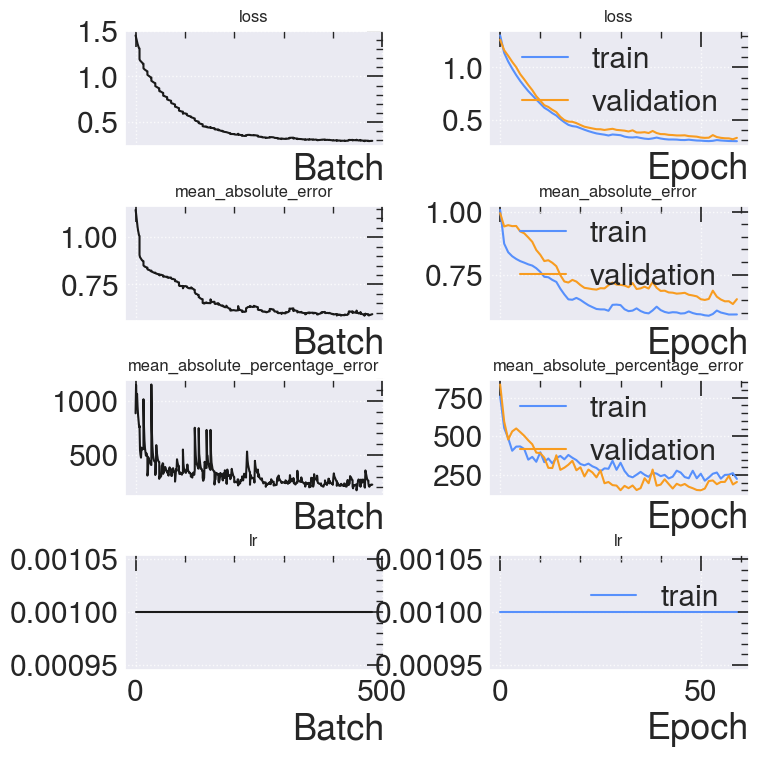

In [98]:
print(loss_history.epochs['lr'])

PlotHistory(loss_history, path=tagdir)

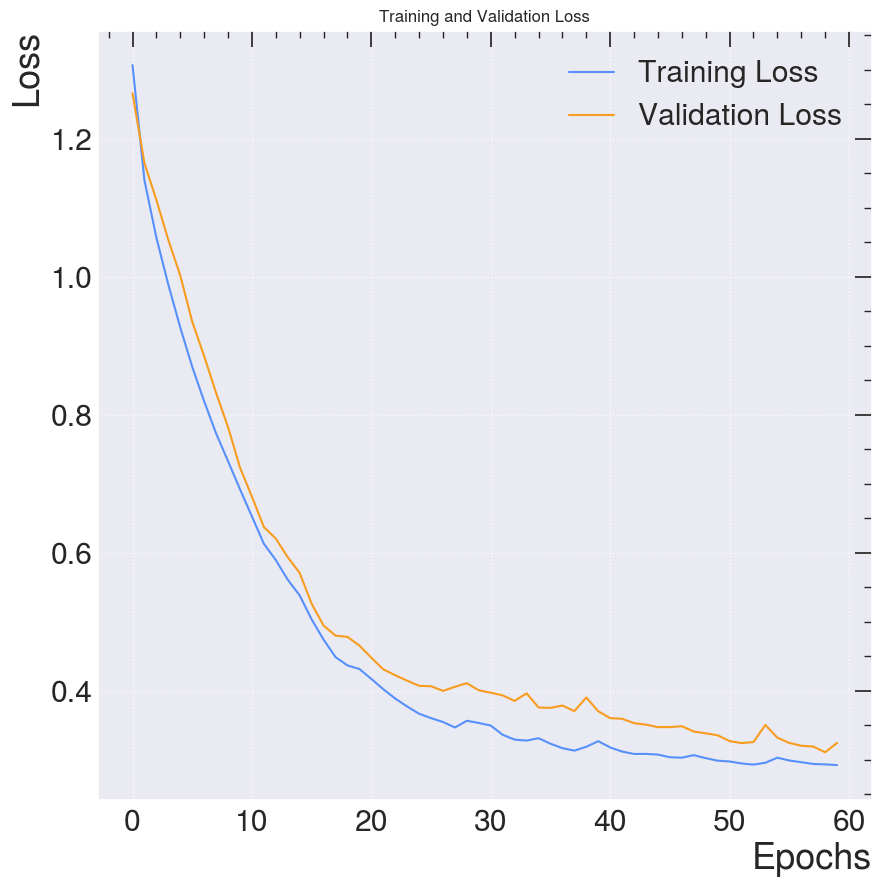

In [99]:
loss_history.plot()


In [100]:
#if not train:
#    model = loadmodel
target_reg_val_train   = model.predict(fit_inputs)
target_val_train = y_train
target_reg_val_test    = model.predict(fit_tests)
target_val_test  = y_test


970/970 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [101]:
print(scaler_y)
if scaler_y is not None:
    target_reg_val_train = scaler_y.inverse_transform(target_reg_val_train)
    target_val_train     = scaler_y.inverse_transform(target_val_train)
    target_reg_val_test  = scaler_y.inverse_transform(target_reg_val_test)
    target_val_test      = scaler_y.inverse_transform(target_val_test)

StandardScaler()


In [102]:
target_regr = None
target_true = None
if evaluate:
    target_regr = np.concatenate((target_reg_val_train, target_reg_val_test), axis=0)
    target_true = np.concatenate((target_val_train, target_val_test), axis=0)



## Extract LBN layer from the model

In [ ]:
##layer = model.get_layer('LBN')
##print(layer)


In [103]:
def plot1D(arrs, keys, bins, span, logy):
    fig, ax = plt.subplots(figsize=(6, 4))
    for i in range(len(arrs)):
        arr = arrs[i]
        key = keys[i]
        ax.hist(arr, bins=bins, range=span, alpha=0.8, label = key, log=logy)
        ax.set_xlabel(key)
    plt.tight_layout()
    plt.show()

In [ ]:
layer_name = 'LBN'
intermediate_layer_model = tf.keras.Model(inputs=model.input,
                                          outputs=model.get_layer(layer_name).output)
intermediate_output = intermediate_layer_model(fit_inputs)

In [ ]:
intermediate_output
#for i in range(intermediate_output.shape[-1]):
#    arr = intermediate_output[:,i:i+1].numpy()
#    plot1D([arr], [""], 50, None, True)

In [ ]:


intermediate_output[:,0:1]

2025-03-17:10:05:12,599 INFO     [1080615791.py:19] Plot saved: /pbs/home/o/oponcet/private/TauRegression/BasicNN/DNN_Higgs_Flat_Feb25/output_test_events_a1a1_new_nPart_10_executed_on_20250317_095238.png
2025-03-17:10:05:12,599 INFO     [1080615791.py:19] Plot saved: /pbs/home/o/oponcet/private/TauRegression/BasicNN/DNN_Higgs_Flat_Feb25/output_test_events_a1a1_new_nPart_10_executed_on_20250317_095238.png


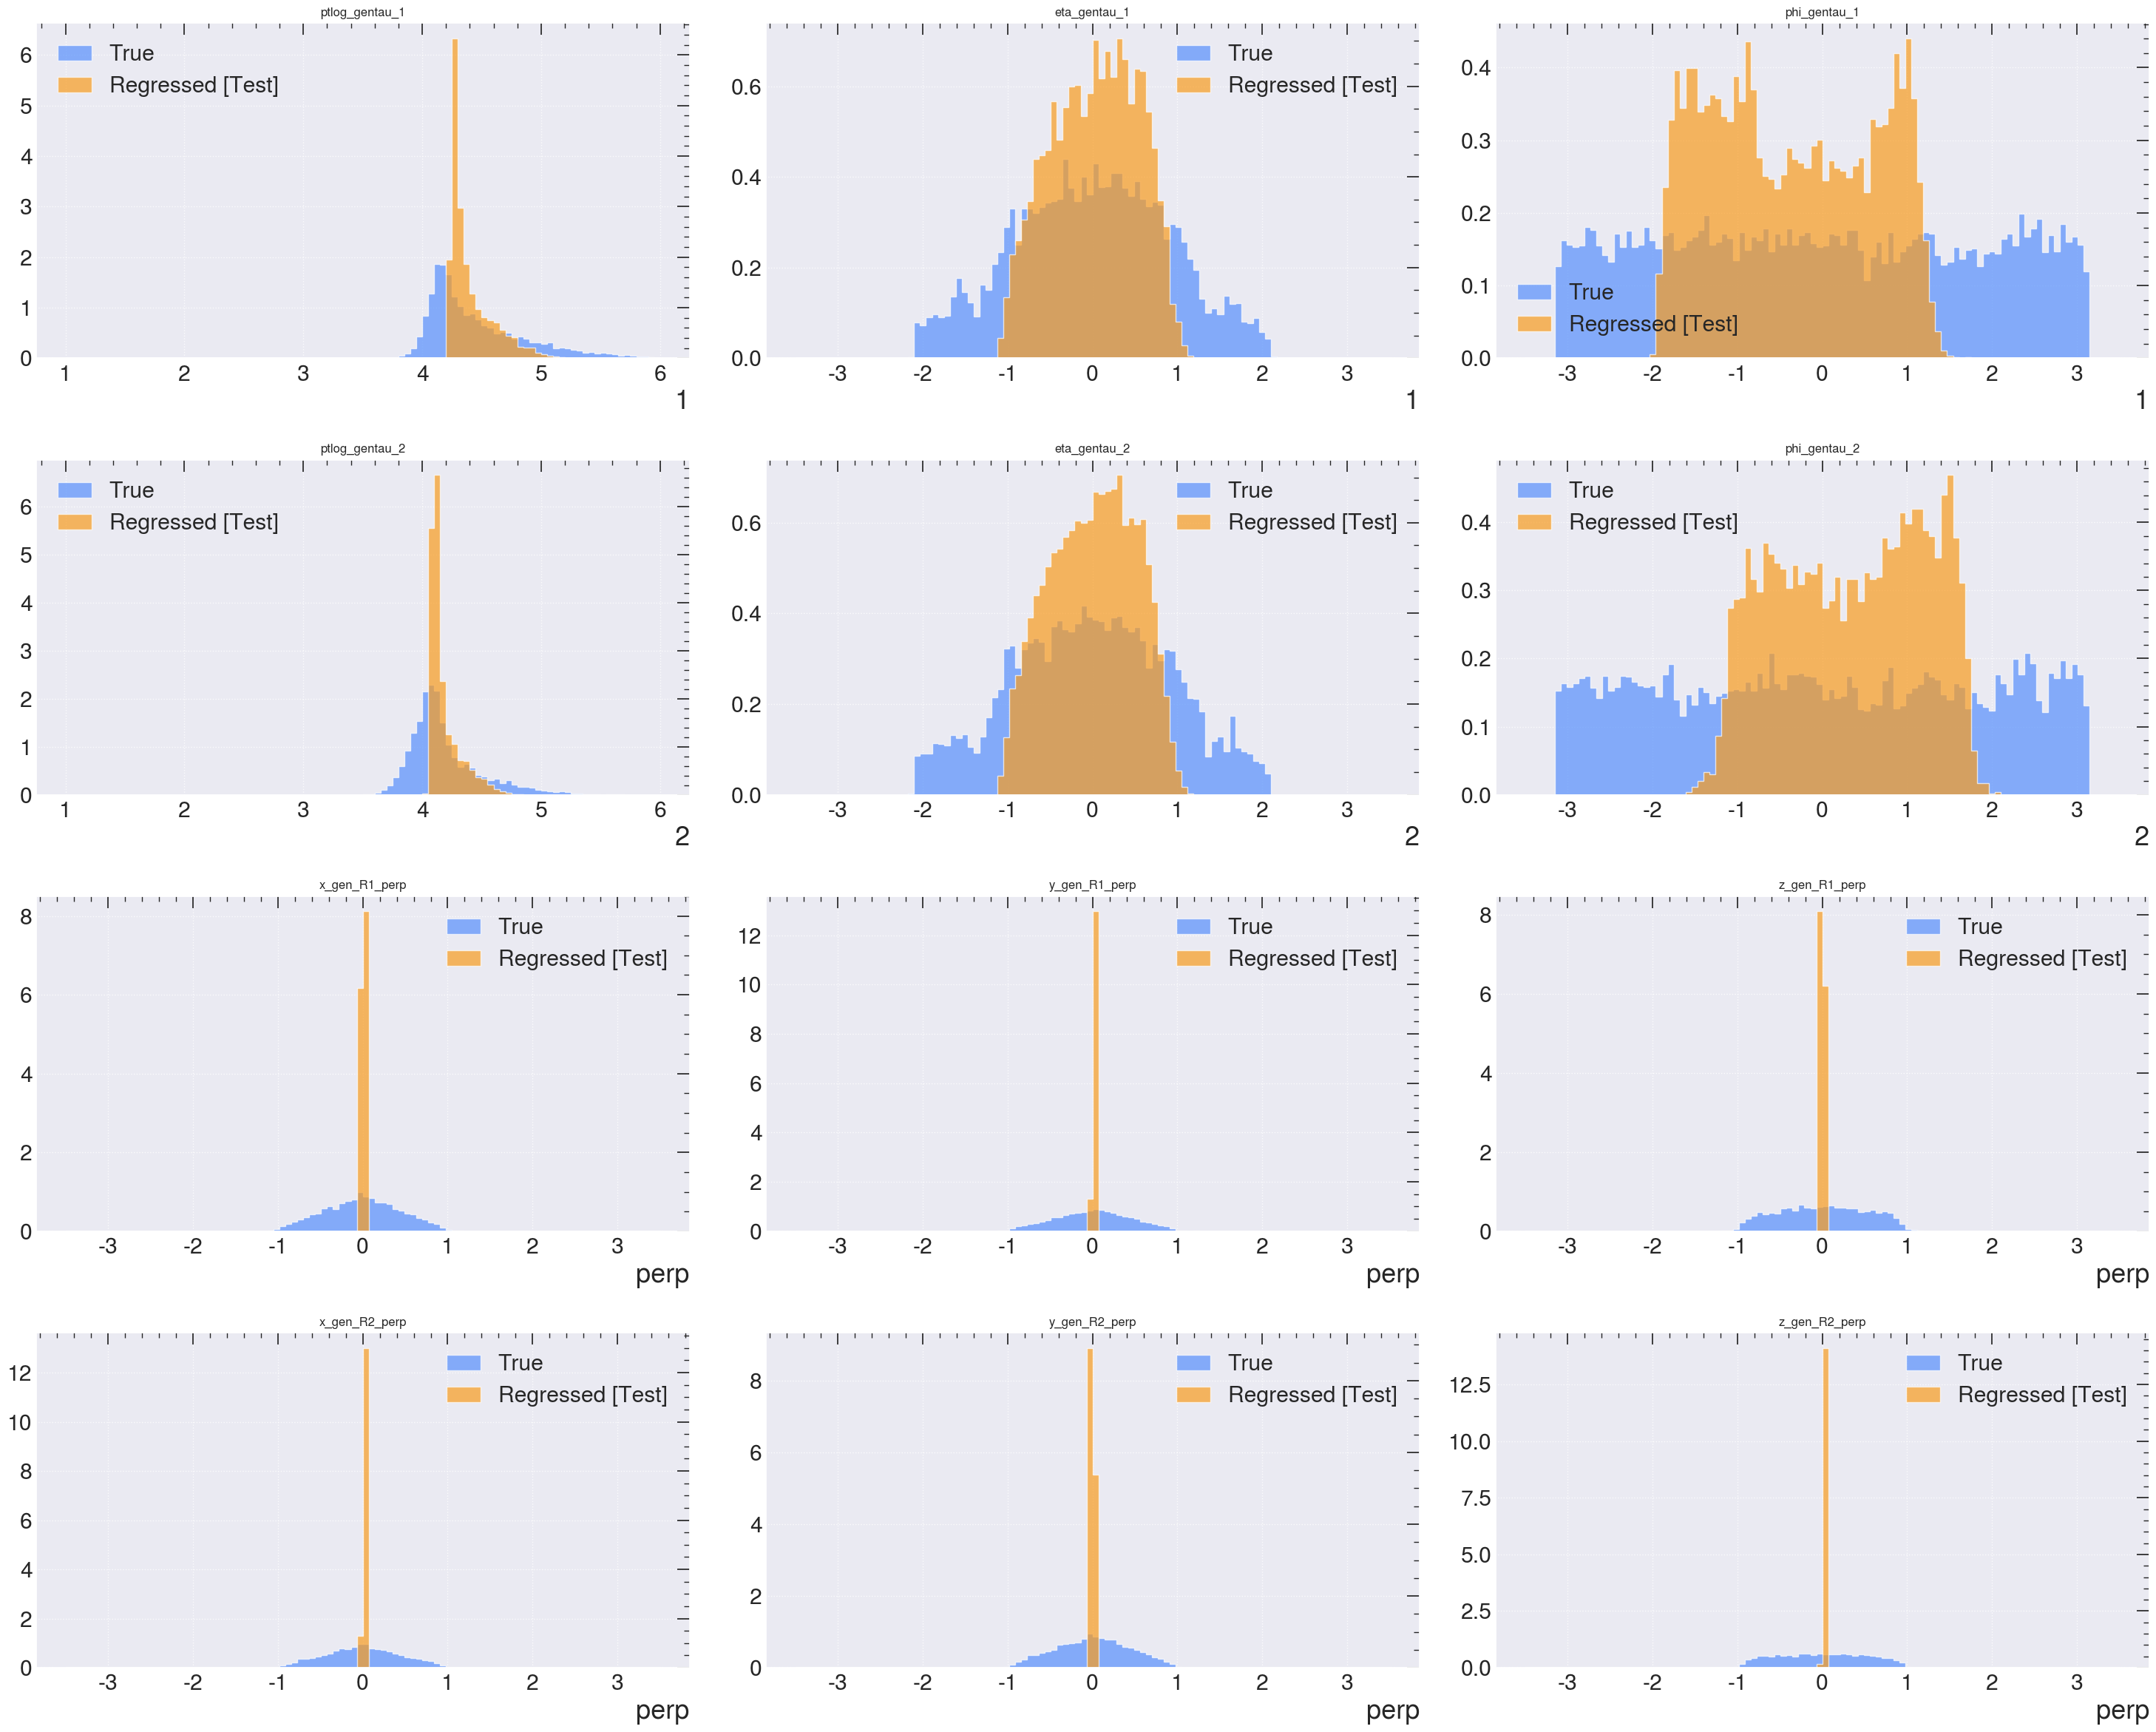

In [107]:
plt.figure(figsize=(30,24))
for idx, key in enumerate(targets):
    idx=idx+1
    ax = plt.subplot(4,3,idx)
    arr_true = target_val_test[:,(idx-1):idx].reshape(-1)
    arr_pred = target_reg_val_test[:,(idx-1):idx].reshape(-1)

    #print(arr)
    minmax = [1,6] if idx == 1 or idx == 4 else [-3.5,3.5]
    ax.hist(arr_true, 100, histtype="stepfilled", alpha=0.7, label='True', log=False, density=True,
            range=minmax)
    ax.hist(arr_pred, 100, histtype="stepfilled", alpha=0.7, label='Regressed [Test]', log=False, density=True,
            range=minmax)
    ax.set_title(f"{key}")
    ax.set_xlabel(f"""{key.split('_')[-1]}""")
    ax.legend()

pngname = os.path.join(tagdir,f'output_test_{df_tag_}.png')
logger.info(f"Plot saved: {pngname}")
plt.tight_layout()
plt.savefig(pngname, dpi=300)

In [ ]:
"""
plt.figure(figsize=(20,16))
for idx, key in enumerate(targets):
    idx=idx+1
    ax = plt.subplot(4,3,idx)
    arr_true = target_val_test[:,(idx-1):idx].reshape(-1)
    arr_pred = target_reg_val_test[:,(idx-1):idx].reshape(-1)

    #print(arr)
    minmax = [0,50] #if idx%4 == 0 else [0,6.5]
    ax.hist(np.abs(arr_true), 50, range=minmax, histtype="stepfilled", alpha=0.7, label='True')
    ax.hist(np.abs(arr_pred), 50, range=minmax, histtype="stepfilled", alpha=0.7, label='Regressed [Test]')
    ax.set_title(f"{key}")
    ax.set_xlabel(f"{key.split('_')[-1]}")
    ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(tagdir,'output_test_abs.png'), dpi=300)
"""

In [ ]:
plt.figure(figsize=(30,24))
for idx, key in enumerate(targets):
    idx=idx+1
    ax = plt.subplot(2,3,idx)
    arr_true = target_val_train[:,(idx-1):idx].reshape(-1)
    arr_pred = target_reg_val_train[:,(idx-1):idx].reshape(-1)

    #print(arr)
    #minmax = [-50,50] if np.min(arr_true) < 0 else [0,1]
    minmax = [2,6] if idx == 1 or idx == 4 else [-3.5,3.5]
    ax.hist(arr_true, 100, histtype="stepfilled", alpha=0.7, label='True', 
            log=False, density=True, range=minmax)
    ax.hist(arr_pred, 100, histtype="stepfilled", alpha=0.7, label='Regressed [Train]', 
            log=False, density=True, range=minmax)
    ax.set_title(f"{key}")
    ax.set_xlabel(f'''{key.split('_')[-1]}''')
    ax.legend()

pngname = os.path.join(tagdir,f'output_train_{df_tag_}.png')
logger.info(f"Plot saved: {pngname}")
plt.tight_layout()
plt.savefig(pngname, dpi=300)

In [ ]:
"""
plt.figure(figsize=(20,16))
for idx, key in enumerate(targets):
    idx=idx+1
    ax = plt.subplot(2,3,idx)
    arr_true = target_val_train[:,(idx-1):idx].reshape(-1)
    arr_pred = target_reg_val_train[:,(idx-1):idx].reshape(-1)

    #print(arr)
    minmax = [0,50] #if idx%4 == 0 else [0,50]
    ax.hist(np.abs(arr_true), 50, range=minmax, histtype="stepfilled", alpha=0.7, label='True')
    ax.hist(np.abs(arr_pred), 50, range=minmax, histtype="stepfilled", alpha=0.7, label='Regressed [Train]')
    ax.set_title(f"{key}")
    ax.set_xlabel(f"{key.split('_')[-1]}")
    ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(tagdir,'output_train_abs.png'), dpi=300)
"""

In [ ]:
df_test["pt_gentau_1"].to_numpy()
gentau1p4 = vector.array({"pt" : df_test["pt_gentau_1"].to_numpy(),
                          "eta": df_test["eta_gentau_1"].to_numpy(),
                          "phi": df_test["phi_gentau_1"].to_numpy(),
                          "mass": 1.777*np.ones(df_test.shape[0])})
gentau2p4 = vector.array({"pt" : df_test["pt_gentau_2"].to_numpy(),
                          "eta": df_test["eta_gentau_2"].to_numpy(),
                          "phi": df_test["phi_gentau_2"].to_numpy(),
                          "mass": 1.777*np.ones(df_test.shape[0])})
genhp4 = gentau1p4 + gentau2p4

In [ ]:
genhp4.mass

In [ ]:
regr_tau1_p4 = vector.array({"pt" : np.exp(target_regr[:,:1]).reshape(-1),
                             "eta": target_regr[:,1:2].reshape(-1),
                             "phi": target_regr[:,2:3].reshape(-1),
                             "mass": 1.777*np.ones_like(target_regr[:,:1].reshape(-1))})
regr_tau2_p4 = vector.array({"pt" : np.exp(target_regr[:,3:4]).reshape(-1),
                             "eta": target_regr[:,4:5].reshape(-1),
                             "phi": target_regr[:,5:6].reshape(-1),
                             "mass": 1.777*np.ones_like(target_regr[:,:1].reshape(-1))})

In [ ]:
"""
regr_tau1_p4 = vector.array({"px": target_regr[:,:1].reshape(-1),
                             "py": target_regr[:,1:2].reshape(-1),
                             "pz": target_regr[:,2:3].reshape(-1),
                             "M" : 1.777*np.ones_like(target_regr[:,:1].reshape(-1))})
regr_tau2_p4 = vector.array({"px": target_regr[:,3:4].reshape(-1),
                             "py": target_regr[:,4:5].reshape(-1),
                             "pz": target_regr[:,5:6].reshape(-1),
                             "M" : 1.777*np.ones_like(target_regr[:,:1].reshape(-1))})
"""

In [ ]:
regr_tau1_p4.M, regr_tau2_p4.M

In [ ]:
regr_h_p4 = regr_tau1_p4 + regr_tau2_p4
regr_h_p4.M

In [ ]:
plt.figure(figsize=(8,6))

plt.hist(genhp4.mass, range=[110,140], bins=100, histtype="stepfilled", alpha=0.7, label="visible tau + true nu")
plt.hist(regr_h_p4.M, range=[110,140], bins=100, histtype="stepfilled", alpha=0.7, label="visible tau + regressed nu")
plt.xlabel("$m_{tau-tau}$")
plt.legend()


plt.tight_layout()
pngname = os.path.join(tagdir,f'mass_tau_tau_{df_tag_}.png')
logger.info(f"Plot saved: {pngname}")
plt.savefig(pngname, dpi=300)
plt.show()

In [ ]:
pi1_p4 = getp4(df, vars=["pt_tau1pi_1","eta_tau1pi_1","phi_tau1pi_1","mass_tau1pi_1"], LVtype="ptetaphim")
pi2_p4 = getp4(df, vars=["pt_tau2pi_1","eta_tau2pi_1","phi_tau2pi_1","mass_tau2pi_1"], LVtype="ptetaphim")
pi01_p4 = getp4(df, vars=["pt_tau1pi0_1","eta_tau1pi0_1","phi_tau1pi0_1","mass_tau1pi0_1"], LVtype="ptetaphim")
pi02_p4 = getp4(df, vars=["pt_tau2pi0_1","eta_tau2pi0_1","phi_tau2pi0_1","mass_tau2pi0_1"], LVtype="ptetaphim")

In [ ]:
import awkward as ak
from coffea.nanoevents.methods import vector
def getakp4(tau1_full_p4, pid):
    return ak.zip(
        {
            "pt": ak.Array(tau1_full_p4.pt[:,None]),
            "eta": ak.Array(tau1_full_p4.eta[:,None]),
            "phi": ak.Array(tau1_full_p4.phi[:,None]),
            "mass": ak.Array(tau1_full_p4.mass[:,None]),
            "pdgId": pid*ak.ones_like(ak.Array(tau1_full_p4.mass[:,None])),
        },
        with_name="PtEtaPhiMLorentzVector",
        behavior=vector.behavior
    )

In [ ]:
tau1_full_p4 = getakp4(regr_tau1_p4, 15)
tau2_full_p4 = getakp4(regr_tau2_p4, 15)
pi1_p4 = getakp4(pi1_p4, 211)
pi2_p4 = getakp4(pi2_p4, 211)
pi01_p4 = getakp4(pi01_p4, 111)
pi02_p4 = getakp4(pi02_p4, 111)

In [ ]:
# Construct H mass from tau visible from the decay products pion and pi0
tau1p4_vis = pi1_p4 + pi01_p4
tau2p4_vis = pi2_p4 + pi02_p4
Hp4_vis = tau1p4_vis + tau2p4_vis



In [ ]:
plt.figure(figsize=(8,6))

plt.hist(Hp4_vis.mass, range=[20,140], bins=100, histtype="stepfilled", alpha=0.7)
#plt.hist(regr_h_p4.M, range=[110,140], bins=100, histtype="stepfilled", alpha=0.7, label="visible tau + regressed nu")
plt.xlabel("$m_{\tau-\tau}$ (visible)")
#plt.legend()

plt.tight_layout()
pngname = os.path.join(tagdir,f'mass_tau_tau_vis_{df_tag_}.png')
logger.info(f"Plot saved: {pngname}")
plt.savefig(pngname, dpi=300)
plt.show()

In [ ]:
plt.figure(figsize=(8,6))

plt.hist(pi01_p4.mass, range=[0,0.2], bins=100, histtype="stepfilled", alpha=0.7, label="$m_{\pi 0}^1$")
plt.hist(pi02_p4.mass, range=[0,0.2], bins=100, histtype="stepfilled", alpha=0.7, label="$m_{\pi 0}^2$")
#plt.hist(regr_h_p4.M, range=[110,140], bins=100, histtype="stepfilled", alpha=0.7, label="visible tau + regressed nu")
plt.xlabel("$m_{\pi 0}$ (GeV)")
plt.legend()

plt.tight_layout()
pngname = os.path.join(tagdir,f'mass_pi0s_{df_tag_}.png')
logger.info(f"Plot saved: {pngname}")
plt.savefig(pngname, dpi=300)
plt.show()

In [ ]:
tau1_full_p4.pt, pi02_p4.pt

In [ ]:
tau1_decay = ak.concatenate([pi1_p4,pi01_p4], axis=1)
tau2_decay = ak.concatenate([pi2_p4,pi02_p4], axis=1)
tau1_decay.pt, tau2_decay.pt

In [ ]:
#ak.to_list(tau2_full_p4.pt)

In [ ]:
#ak.to_list(tau2_decay.pt)

In [ ]:
from PhiCPComp import PhiCPComp
phicp_obj = PhiCPComp(cat="rhorho",
                      taum=tau1_full_p4,
                      taup=tau2_full_p4,
                      taum_decay=tau1_decay,
                      taup_decay=tau2_decay)
phi_cp, hk_dict = phicp_obj.comp_phiCP()
phi_cp = ak.firsts(phi_cp, axis=1)
phi_cp

In [ ]:
phicp_det = phi_cp
phicp_gen = ak.Array(df["phicp"])
phicp_det_true_tau = ak.Array(df["phi_cp_det"])
phicp_det, phicp_gen, phicp_det_true_tau

In [ ]:
#plt.figure(12,8)
plt.hist(ak.to_numpy(phicp_det), bins=25, label="Full Det", density=True, alpha=0.9, lw=2, histtype="step")
plt.hist(ak.to_numpy(phicp_det_true_tau), bins=25, label="Gen tau + det decays", density=True, alpha=0.9, lw=2, histtype="step")
plt.hist(ak.to_numpy(phicp_gen), bins=25, label="Full Gen", density=True, alpha=0.9, lw=2, histtype="step")

plt.legend()
plt.tight_layout()
pngname = os.path.join(tagdir,f'PhiCP_{df_tag_}.png')
logger.info(f"Plot saved: {pngname}")
plt.savefig(pngname, dpi=300)
plt.show()

In [ ]:
hk_dict

In [ ]:
conv = lambda x : ak.fill_none(ak.flatten(x),0).to_numpy()

In [ ]:
h1_det = hk_dict["h1_unit"]

h1x_det = conv(h1_det.x)
h1x_gen = df["h1x"].to_numpy()
h1y_det = conv(h1_det.y)
h1y_gen = df["h1y"].to_numpy()
h1z_det = conv(h1_det.z)
h1z_gen = df["h1z"].to_numpy()

h2_det = hk_dict["h2_unit"]

h2x_det = conv(h2_det.x)
h2x_gen = df["h2x"].to_numpy()
h2y_det = conv(h2_det.y)
h2y_gen = df["h2y"].to_numpy()
h2z_det = conv(h2_det.z)
h2z_gen = df["h2z"].to_numpy()

k1_det = hk_dict["k1_unit"]

k1x_det = conv(k1_det.x)
k1x_gen = df["k1x"].to_numpy()
k1y_det = conv(k1_det.y)
k1y_gen = df["k1y"].to_numpy()
k1z_det = conv(k1_det.z)
k1z_gen = df["k1z"].to_numpy()

k2_det = hk_dict["k2_unit"]

k2x_det = conv(k2_det.x)
k2x_gen = df["k2x"].to_numpy()
k2y_det = conv(k2_det.y)
k2y_gen = df["k2y"].to_numpy()
k2z_det = conv(k2_det.z)
k2z_gen = df["k2z"].to_numpy()

In [ ]:
def fastplot(arrs1, arrs2, tag='h'):
    fig, ax = plt.subplots(2,3,figsize=(12.5,8))

    ax[0,0].hist(arrs1[0], 100, histtype="stepfilled", alpha=0.7, label='Gen', log=False, density=True)
    ax[0,0].hist(arrs2[0], 100, histtype="stepfilled", alpha=0.7, label='Reco', log=False, density=True)
    ax[0,0].set_title(f"{tag}1x")
    ax[0,0].legend()
    
    ax[0,1].hist(arrs1[1], 100, histtype="stepfilled", alpha=0.7, label='Gen', log=False, density=True)
    ax[0,1].hist(arrs2[1], 100, histtype="stepfilled", alpha=0.7, label='Reco', log=False, density=True)
    ax[0,1].set_title(f"{tag}1y")
    ax[0,1].legend()

    ax[0,2].hist(arrs1[2], 100, histtype="stepfilled", alpha=0.7, label='Gen', log=False, density=True)
    ax[0,2].hist(arrs2[2], 100, histtype="stepfilled", alpha=0.7, label='Reco', log=False, density=True)
    ax[0,2].set_title(f"{tag}1z")
    ax[0,2].legend()
    
    ax[1,0].hist(arrs1[3], 100, histtype="stepfilled", alpha=0.7, label='Gen', log=False, density=True)
    ax[1,0].hist(arrs2[3], 100, histtype="stepfilled", alpha=0.7, label='Reco', log=False, density=True)
    ax[1,0].set_title(f"{tag}2x")
    ax[1,0].legend()
    
    ax[1,1].hist(arrs1[4], 100, histtype="stepfilled", alpha=0.7, label='Gen', log=False, density=True)
    ax[1,1].hist(arrs2[4], 100, histtype="stepfilled", alpha=0.7, label='Reco', log=False, density=True)
    ax[1,1].set_title(f"{tag}2y")
    ax[1,1].legend()

    ax[1,2].hist(arrs1[5], 100, histtype="stepfilled", alpha=0.7, label='Gen', log=False, density=True)
    ax[1,2].hist(arrs2[5], 100, histtype="stepfilled", alpha=0.7, label='Reco', log=False, density=True)
    ax[1,2].set_title(f"{tag}2z")
    ax[1,2].legend()

    plt.tight_layout()
    pngname = os.path.join(tagdir,f'{tag}_{df_tag_}.png')
    logger.info(f"Plot saved: {pngname}")
    plt.savefig(pngname, dpi=300)

In [ ]:
fastplot([h1x_gen,h1y_gen,h1z_gen,h2x_gen,h2y_gen,h2z_gen],
         [h1x_det,h1y_det,h1z_det,h2x_det,h2y_det,h2z_det], tag='h')

In [ ]:
fastplot([k1x_gen,k1y_gen,k1z_gen,k2x_gen,k2y_gen,k2z_gen],
         [k1x_det,k1y_det,k1z_det,k2x_det,k2y_det,k2z_det], tag='k')